# Topic comparison: Arvamusfestival 2025 vs 2026

The comparison below uses the **same Jev detailed topics and parent dictionary** across years. It shows main-category shares, within-category subtopic changes and subjects only observed in one year. These are descriptive changes in the available recording corpus, which may have unequal programme-area coverage. The report explains denominators, support flags and the difference between global and within-parent changes.

Regenerate the saved comparison from the project root with `uv run --group topic-analysis python scripts/compare_jev_year_topics.py`. No classification API calls or new model fits are made.

This standalone notebook opens with saved charts and tables already visible. Run all cells to reload the saved comparison offline. The exporter command above recalculates the comparison if assignments or metadata change. The comparison covers **114 talks / 2,154 segments in 2025** and **105 talks / 1,978 segments in 2026**. Topics retain the shared fitted vocabulary; “only observed” does not imply a subject appeared or disappeared outside this corpus.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
COMPARISON = ROOT / "data/topic-analysis/results/jev-topic-analysis/year-comparison"
assert (COMPARISON / "manifest.json").exists(), "Run scripts/compare_jev_year_topics.py first"
main_topics = pd.read_csv(COMPARISON / "main-topic-changes.csv")
subtopics = pd.read_csv(COMPARISON / "detailed-topic-changes.csv")
display(pd.read_csv(COMPARISON / "cohorts.csv").round(2))
display(Markdown((COMPARISON / "METHODS.md").read_text()))


,programme_year,talks,segments,hours
0,2025,114,2154,165.38
1,2026,105,1978,152.38


# Topic changes: 2025 vs 2026

This compares **available transcribed recordings**, not the complete festival programmes.
The corpus has 114 talks from 2025 and 105 from 2026. Podcast publication ends in
May 2026 for the 2025 subset and September 2026 for the 2026 subset; programme areas
may have been uploaded in batches. Apparent shifts can therefore reflect recording
availability and selected programme areas, not a change in society or festival-wide
priorities. No claim of significance or causal evolution is made.

The shared 236-topic Jev vocabulary and 20-category dictionary keep labels comparable.
Primary percentages use each year's **total segmented time, including unassigned**.
Talk coverage is the proportion of that year's talks containing a topic; it is
nonadditive. Segment-share and assigned-time-only alternatives are included in CSVs
(unassigned rows should not be interpreted as assigned-time shares).

Within-parent percentages divide each subtopic's time by its category's time in the
same year. A subtopic can gain global share just because its whole category grew;
within-parent changes show shifts in the category's composition. CSV decomposition
splits global change into parent expansion at the old mix, plus mix change at the
new parent size; it is an accounting identity whose components depend on ordering.

“Only observed in 2026/2025” means zero saved primary-label segments in the other
year, not that the subject was newly invented or disappeared. All such topics are
exported. A separate support flag requires at least 10 minutes across 2 talks in the
observed year; sparse examples remain visible. Categories/subtopics have no refit.


## Talks with no topic besides unassigned

A talk counts here when **every current native semantic segment has Jev topic `-1`**: it has zero assigned detailed topics and therefore no assigned high-level category. Talks with even one assigned segment are excluded. This uses saved Jev primary labels, not the original BERTopic outlier labels. Counts describe the transcribed semantic segments, not any untranscribed recording portions.

**Current result:** 2025 has **1 of 114 talks (0.88%)** with only unassigned Jev segments; 2026 has **0 of 105 (0%)**. Combined, that is **1 of 219 (0.46%)**. The talk is **“Milliseid lasteraamatuid tahame – lastega ja lastele”** (2025; episode `2258666735`).


In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display
coverage_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
coverage_out = coverage_root / "data/topic-analysis/results/jev-topic-analysis/year-comparison"
display(pd.read_csv(coverage_out / "talks-only-unassigned-summary.csv").round(2))
only_unassigned_talks = pd.read_csv(coverage_out / "talks-only-unassigned.csv")
if only_unassigned_talks.empty:
    print("No talks are entirely unassigned: every talk has at least one assigned Jev topic.")
else:
    display(only_unassigned_talks)


,programme_year,total_talks,only_unassigned_talks,percent_only_unassigned
0,2025,114,1,0.88
1,2026,105,0,0.00
2,Combined,219,1,0.46


,episode_id,title,segments,assigned_segments,unassigned_segments,programme_year,only_unassigned
0,2258666735,Milliseid lasteraamatuid tahame – lastega ja l...,1,0,1,2025,True


## Main categories and largest detailed-topic changes

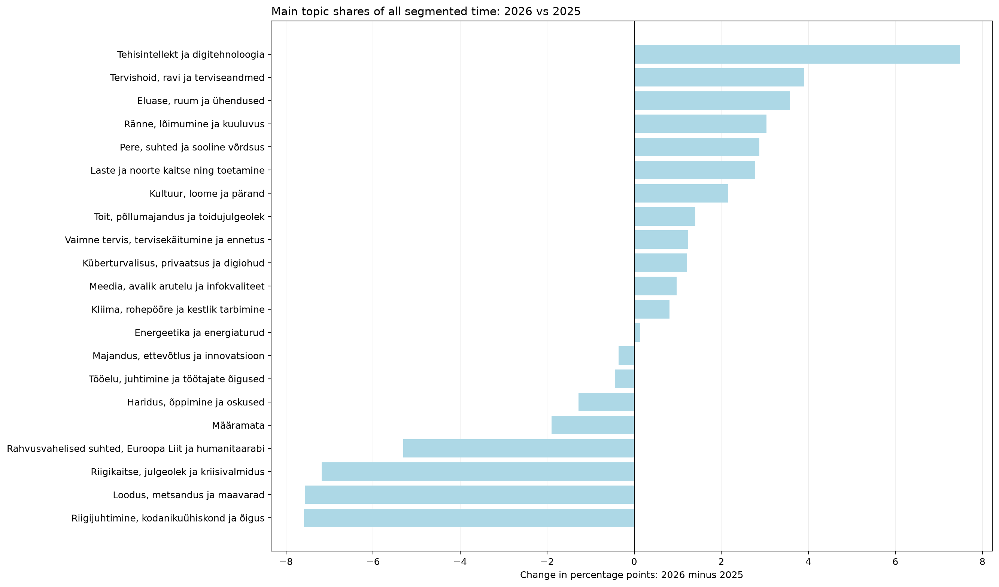

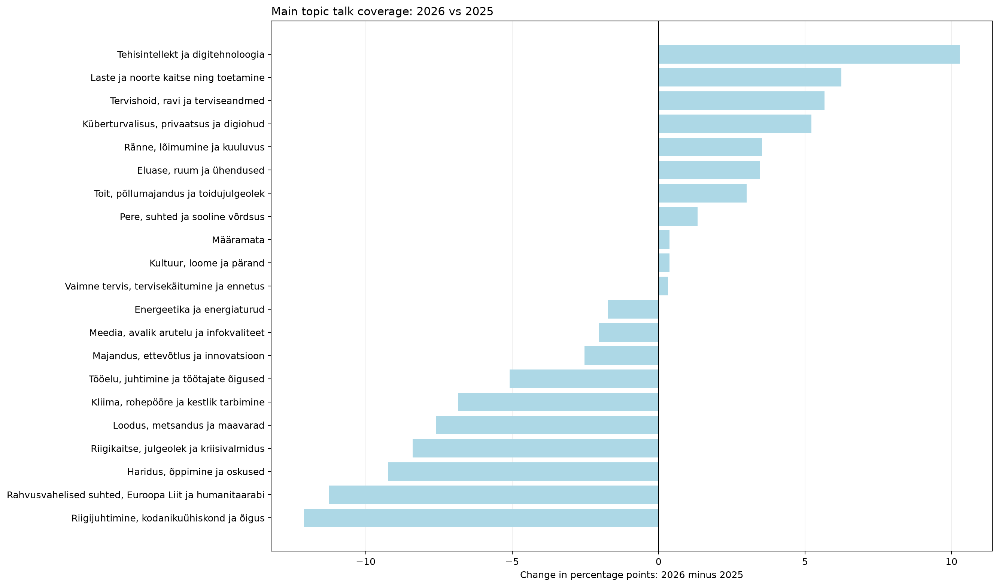

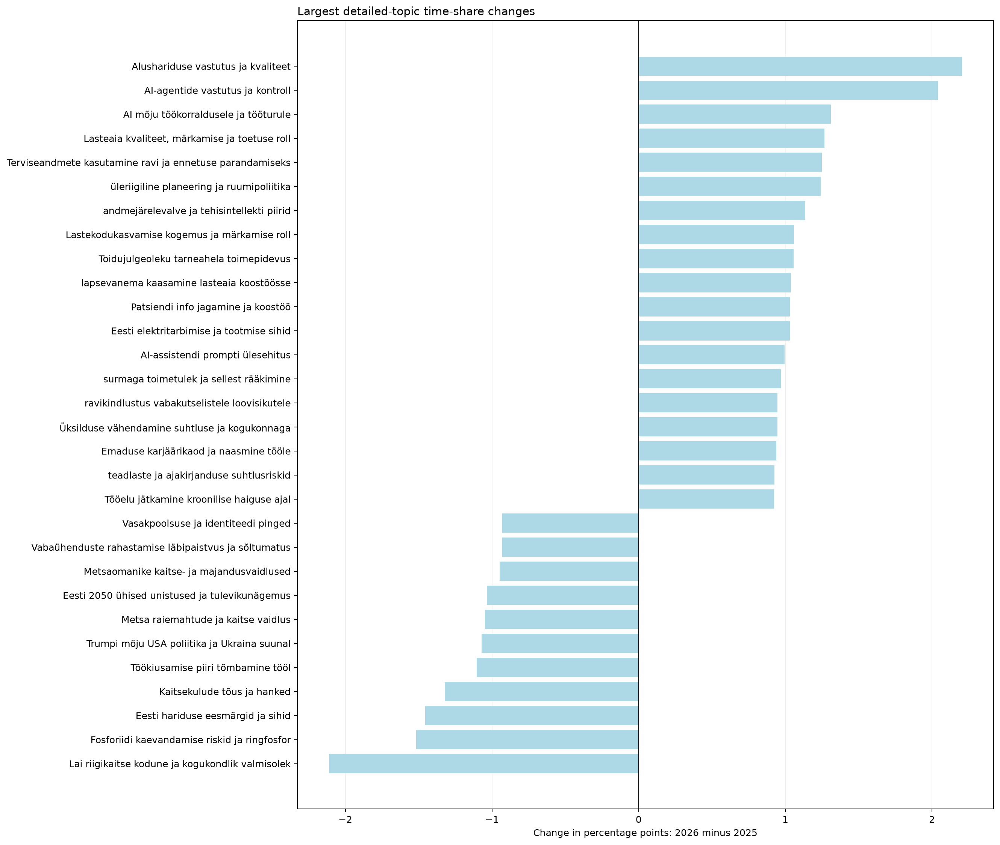

,jev_high_level_id,jev_high_level_name,minutes_2025,minutes_2026,segments_2025,segments_2026,talks_2025,talks_2026,time_share_2025,segment_share_2025,...,segment_share_2026,talk_coverage_2026,assigned_time_share_2026,time_share_delta_pp,segment_share_delta_pp,talk_coverage_delta_pp,assigned_time_share_delta_pp,status,supported_2026,supported_2025
0,ai,Tehisintellekt ja digitehnoloogia,72.91,750.59,20,161,10,20,0.73,0.93,...,8.14,19.05,8.67,7.47,7.21,10.28,7.87,both_years,True,True
12,healthcare,"Tervishoid, ravi ja terviseandmed",679.70,983.83,141,206,12,17,6.85,6.55,...,10.41,16.19,11.36,3.91,3.87,5.66,3.98,both_years,True,True
17,place,"Eluase, ruum ja ühendused",262.31,569.17,53,127,8,11,2.64,2.46,...,6.42,10.48,6.57,3.58,3.96,3.46,3.72,both_years,True,True
15,migration,"Ränne, lõimumine ja kuuluvus",209.67,471.14,46,95,9,12,2.11,2.14,...,4.80,11.43,5.44,3.04,2.67,3.53,3.16,both_years,True,True
9,family,"Pere, suhted ja sooline võrdsus",183.69,431.94,37,92,5,6,1.85,1.72,...,4.65,5.71,4.99,2.87,2.93,1.33,2.99,both_years,True,True
1,children,Laste ja noorte kaitse ning toetamine,233.11,468.72,47,106,7,13,2.35,2.18,...,5.36,12.38,5.41,2.78,3.18,6.24,2.88,both_years,True,True
3,culture,"Kultuur, loome ja pärand",206.10,387.15,40,75,5,5,2.08,1.86,...,3.79,4.76,4.47,2.16,1.93,0.38,2.23,both_years,True,True
10,food,"Toit, põllumajandus ja toidujulgeolek",22.76,149.70,5,34,2,5,0.23,0.23,...,1.72,4.76,1.73,1.41,1.49,3.01,1.48,both_years,True,True
19,wellbeing,"Vaimne tervis, tervisekäitumine ja ennetus",453.01,530.71,102,113,17,16,4.57,4.74,...,5.71,15.24,6.13,1.24,0.98,0.33,1.21,both_years,True,True
4,cyber,"Küberturvalisus, privaatsus ja digiohud",138.11,238.67,31,44,6,11,1.39,1.44,...,2.22,10.48,2.76,1.22,0.79,5.21,1.26,both_years,True,True


In [3]:
for chart in ["main-time-share-changes", "main-talk-coverage-changes", "detailed-time-share-changes"]:
    display(Image(filename=str(COMPARISON / (chart + ".png"))))
display(main_topics.sort_values("time_share_delta_pp", ascending=False).round(2))


## Topics only observed in one year

Complete lists include minutes, talk counts and support flags. A supported observation has at least 10 minutes across two talks in that year. Absence means no segment received that primary label in the saved sample.

In [4]:
for year in [2026, 2025]:
    table = pd.read_csv(COMPARISON / f"only-observed-{year}.csv")
    display(Markdown(f"### Only observed in {year}: {len(table)} topics"))
    display(table.round(2))


### Only observed in 2026: 44 topics

,jev_topic_id,jev_topic_name,jev_high_level_id,jev_high_level_name,minutes_2025,minutes_2026,segments_2025,segments_2026,talks_2025,talks_2026,...,talk_coverage_delta_pp,assigned_time_share_delta_pp,status,supported_2026,supported_2025,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,parent_scale_component_pp,within_parent_mix_component_pp
0,172.0,Alushariduse vastutus ja kvaliteet,education,"Haridus, õppimine ja oskused",0.0,201.50,0.0,42.0,0.0,7.0,...,6.67,2.33,only_observed_2026,True,False,0.0,17.71,17.71,-0.0,2.20
1,48.0,Toidujulgeoleku tarneahela toimepidevus,food,"Toit, põllumajandus ja toidujulgeolek",0.0,96.51,0.0,21.0,0.0,4.0,...,3.81,1.11,only_observed_2026,True,False,0.0,64.47,64.47,0.0,1.06
2,15.0,lapsevanema kaasamine lasteaia koostöösse,education,"Haridus, õppimine ja oskused",0.0,95.00,0.0,18.0,0.0,3.0,...,2.86,1.10,only_observed_2026,True,False,0.0,8.35,8.35,-0.0,1.04
3,77.0,ravikindlustus vabakutselistele loovisikutele,culture,"Kultuur, loome ja pärand",0.0,86.47,0.0,15.0,0.0,2.0,...,1.90,1.00,only_observed_2026,True,False,0.0,22.33,22.33,0.0,0.95
4,19.0,teadlaste ja ajakirjanduse suhtlusriskid,media,"Meedia, avalik arutelu ja infokvaliteet",0.0,84.56,0.0,19.0,0.0,2.0,...,1.90,0.98,only_observed_2026,True,False,0.0,28.80,28.80,0.0,0.92
5,21.0,Tööelu jätkamine kroonilise haiguse ajal,work,"Tööelu, juhtimine ja töötajate õigused",0.0,84.34,0.0,17.0,0.0,1.0,...,0.95,0.97,only_observed_2026,False,False,0.0,13.01,13.01,-0.0,0.92
6,58.0,Türgi hambaravi garantii- ja parandamisvaidlused,healthcare,"Tervishoid, ravi ja terviseandmed",0.0,80.82,0.0,17.0,0.0,1.0,...,0.95,0.93,only_observed_2026,False,False,0.0,8.22,8.22,0.0,0.88
7,109.0,AI päringute energiakulu läbipaistvus,climate,"Kliima, rohepööre ja kestlik tarbimine",0.0,79.82,0.0,16.0,0.0,2.0,...,1.90,0.92,only_observed_2026,True,False,0.0,18.48,18.48,0.0,0.87
8,86.0,"Grafiti, tänavakunsti ja lubade vahe",culture,"Kultuur, loome ja pärand",0.0,78.75,0.0,16.0,0.0,1.0,...,0.95,0.91,only_observed_2026,False,False,0.0,20.34,20.34,0.0,0.86
9,110.0,Perearstikeskuste küberturvalisuse nõuded,cyber,"Küberturvalisus, privaatsus ja digiohud",0.0,78.09,0.0,13.0,0.0,1.0,...,0.95,0.90,only_observed_2026,False,False,0.0,32.72,32.72,0.0,0.85


### Only observed in 2025: 61 topics

,jev_topic_id,jev_topic_name,jev_high_level_id,jev_high_level_name,minutes_2025,minutes_2026,segments_2025,segments_2026,talks_2025,talks_2026,...,talk_coverage_delta_pp,assigned_time_share_delta_pp,status,supported_2026,supported_2025,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,parent_scale_component_pp,within_parent_mix_component_pp
0,45.0,Lai riigikaitse kodune ja kogukondlik valmisolek,defence,"Riigikaitse, julgeolek ja kriisivalmidus",209.54,0.0,44.0,0.0,7.0,0.0,...,-6.14,-2.27,only_observed_2025,False,True,26.07,0.0,-26.07,-1.87,-0.24
1,87.0,Fosforiidi kaevandamise riskid ja ringfosfor,nature,"Loodus, metsandus ja maavarad",150.56,0.0,30.0,0.0,2.0,0.0,...,-1.75,-1.63,only_observed_2025,False,True,19.20,0.0,-19.20,-1.45,-0.06
2,83.0,Kaitsekulude tõus ja hanked,defence,"Riigikaitse, julgeolek ja kriisivalmidus",131.11,0.0,28.0,0.0,7.0,0.0,...,-6.14,-1.42,only_observed_2025,False,True,16.31,0.0,-16.31,-1.17,-0.15
3,200.0,Metsa raiemahtude ja kaitse vaidlus,nature,"Loodus, metsandus ja maavarad",104.10,0.0,24.0,0.0,6.0,0.0,...,-5.26,-1.13,only_observed_2025,False,True,13.28,0.0,-13.28,-1.00,-0.04
4,34.0,Vabaühenduste rahastamise läbipaistvus ja sõlt...,governance,"Riigijuhtimine, kodanikuühiskond ja õigus",92.40,0.0,20.0,0.0,2.0,0.0,...,-1.75,-1.00,only_observed_2025,False,True,9.98,0.0,-9.98,-0.76,-0.17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,227.0,Põlevkivile õigustava teadlase valimine,media,"Meedia, avalik arutelu ja infokvaliteet",18.02,0.0,5.0,0.0,1.0,0.0,...,-0.88,-0.20,only_observed_2025,False,False,8.13,0.0,-8.13,0.08,-0.26
57,221.0,Metsa istandike rajamine ja regulatsioon,nature,"Loodus, metsandus ja maavarad",16.95,0.0,4.0,0.0,1.0,0.0,...,-0.88,-0.18,only_observed_2025,False,False,2.16,0.0,-2.16,-0.16,-0.01
58,192.0,Rahapõhine abi humanitaarkriisides,international,"Rahvusvahelised suhted, Euroopa Liit ja humani...",14.19,0.0,5.0,0.0,1.0,0.0,...,-0.88,-0.15,only_observed_2025,False,False,2.30,0.0,-2.30,-0.12,-0.02
59,215.0,Laulupeo ja Pätsi ümber käiv väärinfo,media,"Meedia, avalik arutelu ja infokvaliteet",13.60,0.0,4.0,0.0,1.0,0.0,...,-0.88,-0.15,only_observed_2025,False,False,6.14,0.0,-6.14,0.06,-0.20


## Tehisintellekt ja digitehnoloogia

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

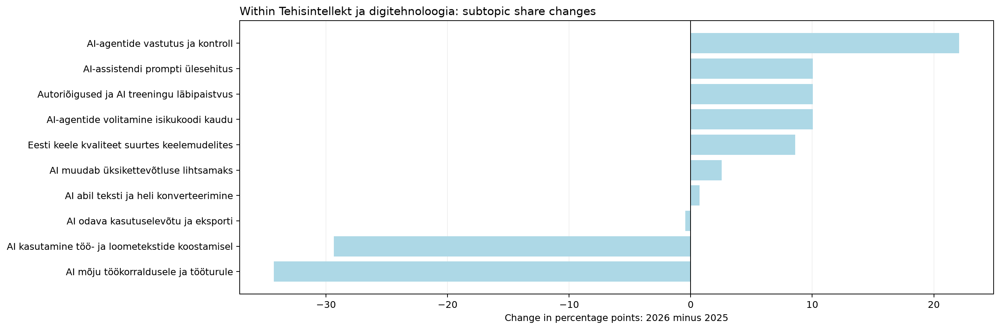

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
156,AI-agentide vastutus ja kontroll,2.21,188.61,1.0,9.0,0.02,2.06,2.04,3.03,25.13,22.10,both_years,False,True
10,AI-assistendi prompti ülesehitus,1.66,92.51,1.0,2.0,0.02,1.01,1.00,2.27,12.32,10.05,both_years,False,True
113,Autoriõigused ja AI treeningu läbipaistvus,0.00,75.37,0.0,3.0,0.00,0.82,0.82,0.00,10.04,10.04,only_observed_2026,False,True
7,AI-agentide volitamine isikukoodi kaudu,0.00,75.36,0.0,3.0,0.00,0.82,0.82,0.00,10.04,10.04,only_observed_2026,False,True
50,Eesti keele kvaliteet suurtes keelemudelites,0.00,64.63,0.0,5.0,0.00,0.71,0.71,0.00,8.61,8.61,only_observed_2026,False,True
235,AI muudab üksikettevõtluse lihtsamaks,2.69,46.73,1.0,4.0,0.03,0.51,0.48,3.68,6.23,2.54,both_years,False,True
171,AI abil teksti ja heli konverteerimine,0.00,5.39,0.0,1.0,0.00,0.06,0.06,0.00,0.72,0.72,only_observed_2026,False,False
121,AI odava kasutuselevõtu ja eksporti,3.33,30.86,1.0,2.0,0.03,0.34,0.30,4.57,4.11,-0.45,both_years,False,True
200,AI kasutamine töö- ja loometekstide koostamisel,22.79,14.28,4.0,4.0,0.23,0.16,-0.07,31.25,1.90,-29.35,both_years,True,True
187,AI mõju töökorraldusele ja tööturule,40.24,156.86,7.0,12.0,0.41,1.72,1.31,55.19,20.90,-34.30,both_years,True,True


In [5]:
display(Image(filename=str(COMPARISON / "subtopics-ai.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("ai")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Laste ja noorte kaitse ning toetamine

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

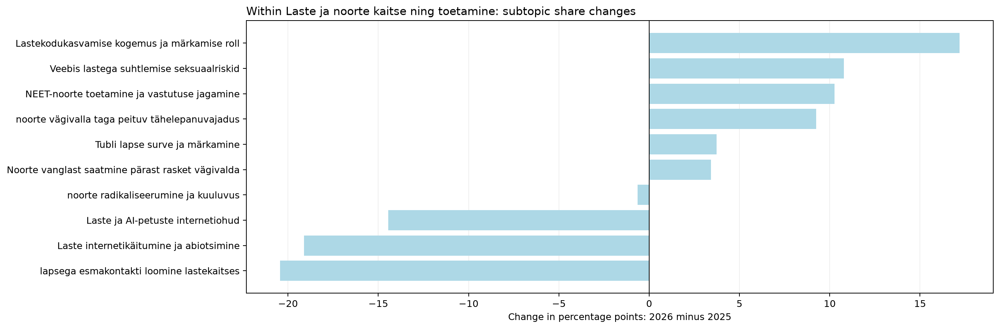

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
37,Lastekodukasvamise kogemus ja märkamise roll,14.89,110.47,1.0,3.0,0.15,1.21,1.06,6.39,23.57,17.18,both_years,False,True
96,Veebis lastega suhtlemise seksuaalriskid,16.27,83.27,3.0,1.0,0.16,0.91,0.75,6.98,17.77,10.79,both_years,True,False
67,NEET-noorte toetamine ja vastutuse jagamine,12.55,73.33,3.0,3.0,0.13,0.80,0.68,5.39,15.64,10.26,both_years,True,True
184,noorte vägivalla taga peituv tähelepanuvajadus,0.00,43.38,0.0,1.0,0.00,0.47,0.47,0.00,9.25,9.25,only_observed_2026,False,False
126,Tubli lapse surve ja märkamine,5.03,27.58,1.0,2.0,0.05,0.30,0.25,2.16,5.88,3.73,both_years,False,True
233,Noorte vanglast saatmine pärast rasket vägivalda,0.00,16.01,0.0,1.0,0.00,0.18,0.18,0.00,3.42,3.42,only_observed_2026,False,False
1,noorte radikaliseerumine ja kuuluvus,44.66,86.78,1.0,3.0,0.45,0.95,0.50,19.16,18.51,-0.64,both_years,False,True
77,Laste ja AI-petuste internetiohud,42.11,16.99,1.0,3.0,0.42,0.19,-0.24,18.07,3.63,-14.44,both_years,False,True
210,Laste internetikäitumine ja abiotsimine,47.19,5.34,4.0,1.0,0.48,0.06,-0.42,20.25,1.14,-19.11,both_years,True,False
130,lapsega esmakontakti loomine lastekaitses,50.41,5.58,1.0,2.0,0.51,0.06,-0.45,21.62,1.19,-20.43,both_years,False,False


In [6]:
display(Image(filename=str(COMPARISON / "subtopics-children.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("children")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Kliima, rohepööre ja kestlik tarbimine

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

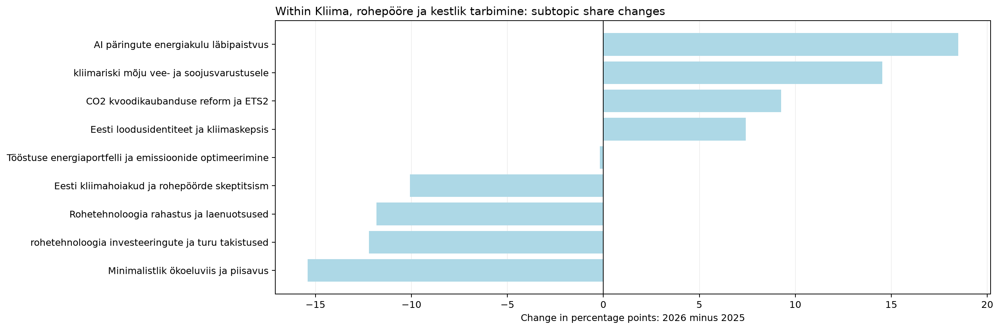

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
110,AI päringute energiakulu läbipaistvus,0.00,79.82,0.0,2.0,0.00,0.87,0.87,0.00,18.48,18.48,only_observed_2026,False,True
38,kliimariski mõju vee- ja soojusvarustusele,11.40,75.42,2.0,4.0,0.11,0.82,0.71,2.94,17.46,14.53,both_years,True,True
153,CO2 kvoodikaubanduse reform ja ETS2,23.94,66.67,4.0,3.0,0.24,0.73,0.49,6.17,15.44,9.27,both_years,True,True
177,Eesti loodusidentiteet ja kliimaskepsis,3.24,35.67,2.0,2.0,0.03,0.39,0.36,0.84,8.26,7.42,both_years,False,True
45,Tööstuse energiaportfelli ja emissioonide opti...,24.46,26.46,3.0,2.0,0.25,0.29,0.04,6.30,6.13,-0.18,both_years,True,True
25,Eesti kliimahoiakud ja rohepöörde skeptitsism,115.72,85.26,10.0,5.0,1.17,0.93,-0.23,29.82,19.74,-10.08,both_years,True,True
6,Rohetehnoloogia rahastus ja laenuotsused,54.14,9.21,4.0,1.0,0.55,0.10,-0.44,13.95,2.13,-11.82,both_years,True,False
217,rohetehnoloogia investeeringute ja turu takist...,95.36,53.38,12.0,5.0,0.96,0.58,-0.38,24.58,12.36,-12.22,both_years,True,True
145,Minimalistlik ökoeluviis ja piisavus,59.76,0.00,2.0,0.0,0.60,0.00,-0.60,15.40,0.00,-15.40,only_observed_2025,True,False


In [7]:
display(Image(filename=str(COMPARISON / "subtopics-climate.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("climate")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Kultuur, loome ja pärand

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

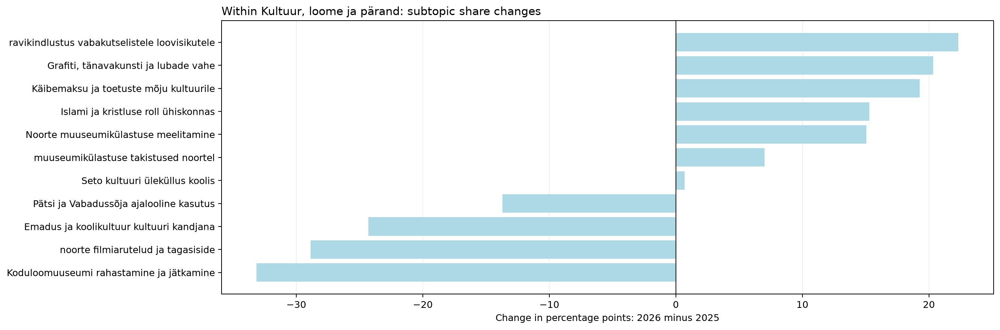

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
78,ravikindlustus vabakutselistele loovisikutele,0.00,86.47,0.0,2.0,0.00,0.95,0.95,0.00,22.33,22.33,only_observed_2026,False,True
87,"Grafiti, tänavakunsti ja lubade vahe",0.00,78.75,0.0,1.0,0.00,0.86,0.86,0.00,20.34,20.34,only_observed_2026,False,False
60,Käibemaksu ja toetuste mõju kultuurile,0.00,74.65,0.0,2.0,0.00,0.82,0.82,0.00,19.28,19.28,only_observed_2026,False,True
27,Islami ja kristluse roll ühiskonnas,0.00,59.20,0.0,1.0,0.00,0.65,0.65,0.00,15.29,15.29,only_observed_2026,False,False
206,Noorte muuseumikülastuse meelitamine,0.00,58.28,0.0,1.0,0.00,0.64,0.64,0.00,15.05,15.05,only_observed_2026,False,False
178,muuseumikülastuse takistused noortel,0.00,27.15,0.0,1.0,0.00,0.30,0.30,0.00,7.01,7.01,only_observed_2026,False,False
163,Seto kultuuri üleküllus koolis,0.00,2.65,0.0,1.0,0.00,0.03,0.03,0.00,0.68,0.68,only_observed_2026,False,False
166,Pätsi ja Vabadussõja ajalooline kasutus,28.23,0.00,1.0,0.0,0.28,0.00,-0.28,13.70,0.00,-13.70,only_observed_2025,False,False
165,Emadus ja koolikultuur kultuuri kandjana,50.08,0.00,2.0,0.0,0.50,0.00,-0.50,24.30,0.00,-24.30,only_observed_2025,True,False
127,noorte filmiarutelud ja tagasiside,59.49,0.00,1.0,0.0,0.60,0.00,-0.60,28.86,0.00,-28.86,only_observed_2025,False,False


In [8]:
display(Image(filename=str(COMPARISON / "subtopics-culture.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("culture")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Küberturvalisus, privaatsus ja digiohud

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

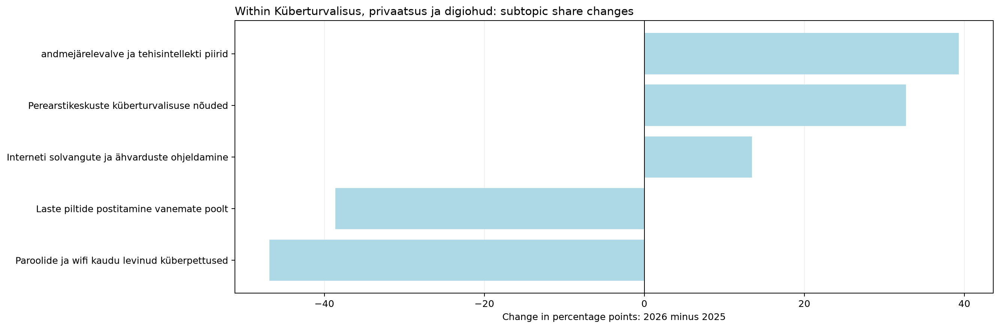

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
61,andmejärelevalve ja tehisintellekti piirid,12.45,115.36,3.0,9.0,0.13,1.26,1.14,9.02,48.33,39.32,both_years,True,True
111,Perearstikeskuste küberturvalisuse nõuded,0.00,78.09,0.0,1.0,0.00,0.85,0.85,0.00,32.72,32.72,only_observed_2026,False,False
155,Interneti solvangute ja ähvarduste ohjeldamine,7.58,45.21,2.0,1.0,0.08,0.49,0.42,5.49,18.94,13.46,both_years,False,False
42,Laste piltide postitamine vanemate poolt,53.33,0.00,1.0,0.0,0.54,0.00,-0.54,38.62,0.00,-38.62,only_observed_2025,False,False
64,Paroolide ja wifi kaudu levinud küberpettused,64.75,0.00,1.0,0.0,0.65,0.00,-0.65,46.88,0.00,-46.88,only_observed_2025,False,False


In [9]:
display(Image(filename=str(COMPARISON / "subtopics-cyber.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("cyber")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Riigikaitse, julgeolek ja kriisivalmidus

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

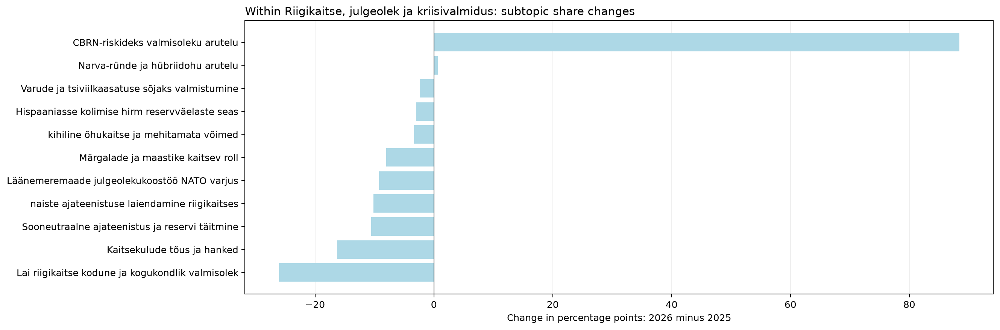

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
97,CBRN-riskideks valmisoleku arutelu,0.00,74.42,0.0,1.0,0.00,0.81,0.81,0.00,88.43,88.43,only_observed_2026,False,False
53,Narva-ründe ja hübriidohu arutelu,57.36,6.55,1.0,2.0,0.58,0.07,-0.51,7.14,7.79,0.65,both_years,False,False
81,Varude ja tsiviilkaasatuse sõjaks valmistumine,49.53,3.19,2.0,2.0,0.50,0.03,-0.46,6.16,3.79,-2.37,both_years,True,False
103,Hispaaniasse kolimise hirm reservväelaste seas,24.47,0.00,1.0,0.0,0.25,0.00,-0.25,3.04,0.00,-3.04,only_observed_2025,False,False
190,kihiline õhukaitse ja mehitamata võimed,26.86,0.00,2.0,0.0,0.27,0.00,-0.27,3.34,0.00,-3.34,only_observed_2025,True,False
92,Märgalade ja maastike kaitsev roll,64.47,0.00,1.0,0.0,0.65,0.00,-0.65,8.02,0.00,-8.02,only_observed_2025,False,False
30,Läänemeremaade julgeolekukoostöö NATO varjus,74.12,0.00,3.0,0.0,0.75,0.00,-0.75,9.22,0.00,-9.22,only_observed_2025,True,False
101,naiste ajateenistuse laiendamine riigikaitses,81.80,0.00,3.0,0.0,0.82,0.00,-0.82,10.18,0.00,-10.18,only_observed_2025,True,False
107,Sooneutraalne ajateenistus ja reservi täitmine,84.60,0.00,4.0,0.0,0.85,0.00,-0.85,10.52,0.00,-10.52,only_observed_2025,True,False
84,Kaitsekulude tõus ja hanked,131.11,0.00,7.0,0.0,1.32,0.00,-1.32,16.31,0.00,-16.31,only_observed_2025,True,False


In [10]:
display(Image(filename=str(COMPARISON / "subtopics-defence.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("defence")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Majandus, ettevõtlus ja innovatsioon

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

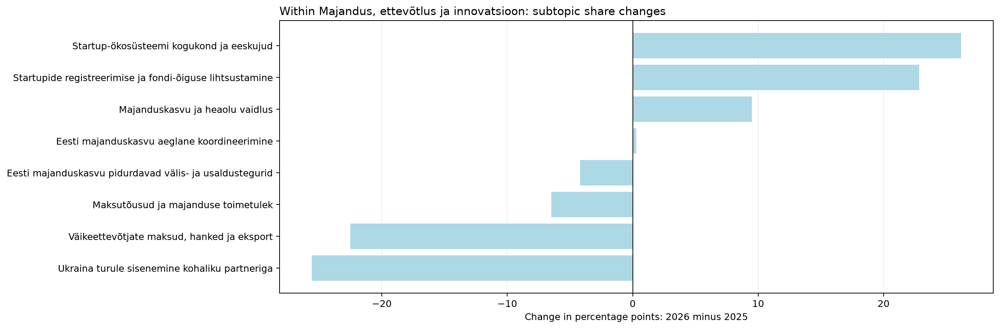

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
158,Startup-ökosüsteemi kogukond ja eeskujud,9.21,74.62,2.0,3.0,0.09,0.82,0.72,2.93,29.10,26.16,both_years,False,True
124,Startupide registreerimise ja fondi-õiguse lih...,0.00,58.54,0.0,2.0,0.00,0.64,0.64,0.00,22.83,22.83,only_observed_2026,False,True
170,Majanduskasvu ja heaolu vaidlus,52.27,67.11,9.0,3.0,0.53,0.73,0.21,16.66,26.17,9.51,both_years,True,True
202,Eesti majanduskasvu aeglane koordineerimine,34.54,28.94,2.0,1.0,0.35,0.32,-0.03,11.01,11.29,0.28,both_years,True,False
231,Eesti majanduskasvu pidurdavad välis- ja usald...,15.74,2.10,3.0,1.0,0.16,0.02,-0.14,5.02,0.82,-4.20,both_years,True,False
175,Maksutõusud ja majanduse toimetulek,47.14,21.89,3.0,4.0,0.48,0.24,-0.24,15.02,8.54,-6.48,both_years,True,True
143,"Väikeettevõtjate maksud, hanked ja eksport",74.66,3.26,5.0,2.0,0.75,0.04,-0.72,23.79,1.27,-22.52,both_years,True,False
23,Ukraina turule sisenemine kohaliku partneriga,80.25,0.00,3.0,0.0,0.81,0.00,-0.81,25.57,0.00,-25.57,only_observed_2025,True,False


In [11]:
display(Image(filename=str(COMPARISON / "subtopics-economy.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("economy")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Haridus, õppimine ja oskused

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

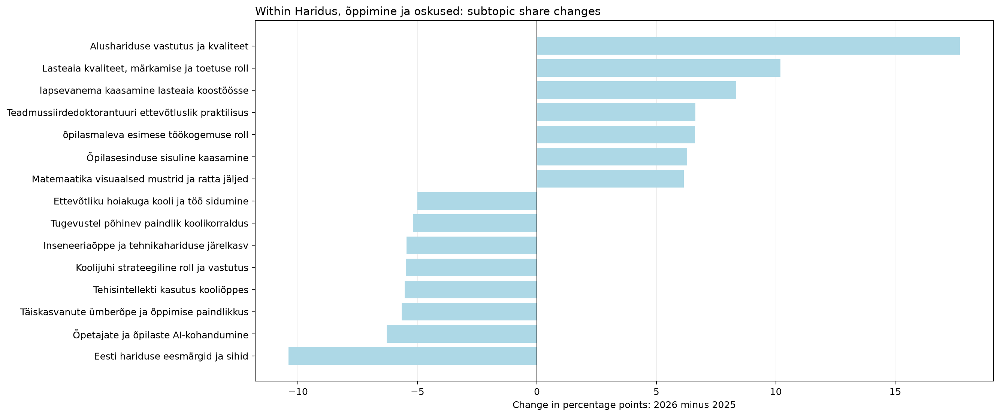

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
173,Alushariduse vastutus ja kvaliteet,0.00,201.50,0.0,7.0,0.00,2.20,2.20,0.00,17.71,17.71,only_observed_2026,False,True
5,"Lasteaia kvaliteet, märkamise ja toetuse roll",2.70,118.33,1.0,5.0,0.03,1.29,1.27,0.20,10.40,10.20,both_years,False,True
16,lapsevanema kaasamine lasteaia koostöösse,0.00,95.00,0.0,3.0,0.00,1.04,1.04,0.00,8.35,8.35,only_observed_2026,False,True
26,Teadmussiirdedoktorantuuri ettevõtluslik prakt...,16.40,89.25,2.0,3.0,0.17,0.98,0.81,1.20,7.84,6.64,both_years,True,True
24,õpilasmaleva esimese töökogemuse roll,10.36,83.94,1.0,2.0,0.10,0.92,0.81,0.76,7.38,6.62,both_years,False,True
136,Õpilasesinduse sisuline kaasamine,0.00,71.63,0.0,1.0,0.00,0.78,0.78,0.00,6.29,6.29,only_observed_2026,False,False
176,Matemaatika visuaalsed mustrid ja ratta jäljed,0.00,69.94,0.0,2.0,0.00,0.76,0.76,0.00,6.15,6.15,only_observed_2026,False,True
181,Õpetaja hoituse rollid alushariduses,0.00,51.70,0.0,1.0,0.00,0.57,0.57,0.00,4.54,4.54,only_observed_2026,False,False
108,Fookuse hoidmise liikumismängud,0.00,42.83,0.0,1.0,0.00,0.47,0.47,0.00,3.76,3.76,only_observed_2026,False,False
89,AI kasutamise reeglid ja hindamine ülikoolis,0.00,39.77,0.0,1.0,0.00,0.43,0.43,0.00,3.49,3.49,only_observed_2026,False,False


In [12]:
display(Image(filename=str(COMPARISON / "subtopics-education.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("education")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Energeetika ja energiaturud

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

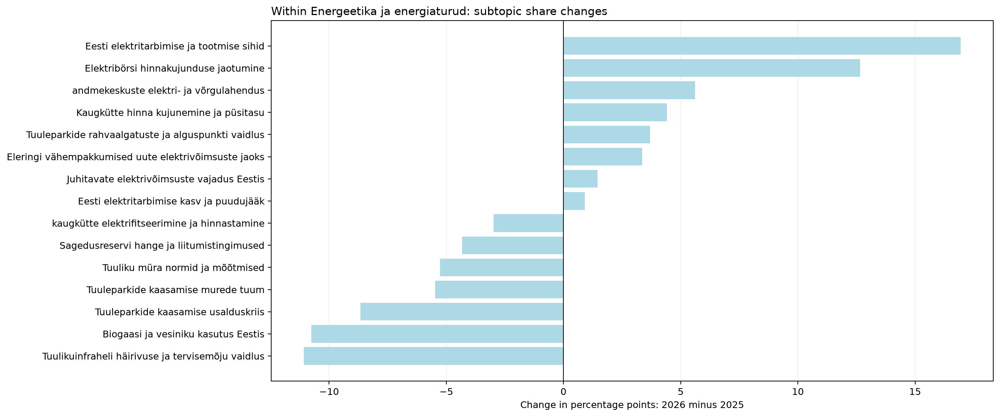

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
133,Eesti elektritarbimise ja tootmise sihid,26.45,118.64,4.0,7.0,0.27,1.30,1.03,4.51,21.45,16.94,both_years,True,True
128,Elektribörsi hinnakujunduse jaotumine,4.79,74.51,1.0,3.0,0.05,0.81,0.77,0.82,13.47,12.65,both_years,False,True
195,andmekeskuste elektri- ja võrgulahendus,0.00,31.06,0.0,3.0,0.00,0.34,0.34,0.00,5.61,5.61,only_observed_2026,False,True
118,Kaugkütte hinna kujunemine ja püsitasu,16.31,39.82,1.0,1.0,0.16,0.44,0.27,2.78,7.20,4.42,both_years,False,False
236,Tuuleparkide rahvaalgatuste ja alguspunkti vai...,0.00,20.46,0.0,1.0,0.00,0.22,0.22,0.00,3.70,3.70,only_observed_2026,False,False
224,Eleringi vähempakkumised uute elektrivõimsuste...,3.84,22.16,1.0,3.0,0.04,0.24,0.20,0.65,4.01,3.35,both_years,False,True
161,Juhitavate elektrivõimsuste vajadus Eestis,101.73,103.98,3.0,4.0,1.03,1.14,0.11,17.35,18.80,1.45,both_years,True,True
182,Eesti elektritarbimise kasv ja puudujääk,12.01,16.39,2.0,3.0,0.12,0.18,0.06,2.05,2.96,0.91,both_years,True,True
157,Meretuuleparkide arendamise kindlustamine,14.19,10.61,1.0,1.0,0.14,0.12,-0.03,2.42,1.92,-0.50,both_years,False,False
213,kaugkütte elektrifitseerimine ja hinnastamine,55.69,36.03,2.0,2.0,0.56,0.39,-0.17,9.50,6.51,-2.98,both_years,True,True


In [13]:
display(Image(filename=str(COMPARISON / "subtopics-energy.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("energy")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Pere, suhted ja sooline võrdsus

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

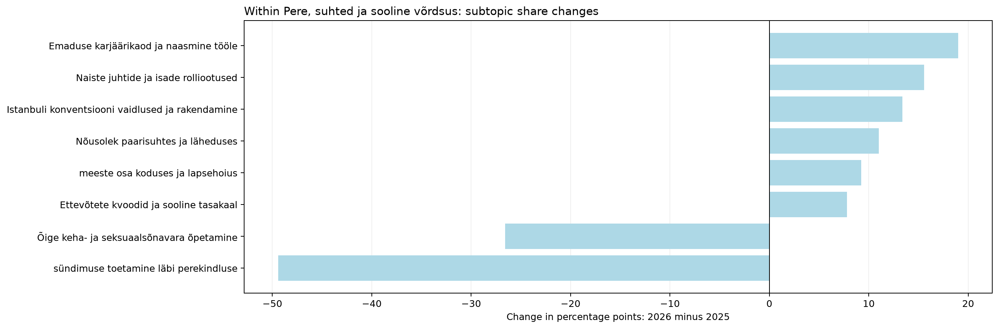

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
14,Emaduse karjäärikaod ja naasmine tööle,2.64,88.32,1.0,3.0,0.03,0.97,0.94,1.44,20.45,19.01,both_years,False,True
151,Naiste juhtide ja isade rolliootused,3.79,76.21,2.0,3.0,0.04,0.83,0.80,2.06,17.64,15.58,both_years,False,True
55,Istanbuli konventsiooni vaidlused ja rakendamine,13.33,89.12,1.0,1.0,0.13,0.97,0.84,7.26,20.63,13.38,both_years,False,False
11,Nõusolek paarisuhtes ja läheduses,15.70,84.48,1.0,1.0,0.16,0.92,0.77,8.55,19.56,11.01,both_years,False,False
186,meeste osa koduses ja lapsehoius,6.52,55.25,1.0,2.0,0.07,0.60,0.54,3.55,12.79,9.24,both_years,False,True
174,Ettevõtete kvoodid ja sooline tasakaal,0.00,33.67,0.0,2.0,0.00,0.37,0.37,0.00,7.80,7.80,only_observed_2026,False,True
41,Õige keha- ja seksuaalsõnavara õpetamine,49.54,1.63,1.0,1.0,0.50,0.02,-0.48,26.97,0.38,-26.59,both_years,False,False
13,sündimuse toetamine läbi perekindluse,92.18,3.26,2.0,1.0,0.93,0.04,-0.89,50.18,0.76,-49.43,both_years,True,False


In [14]:
display(Image(filename=str(COMPARISON / "subtopics-family.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("family")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Toit, põllumajandus ja toidujulgeolek

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

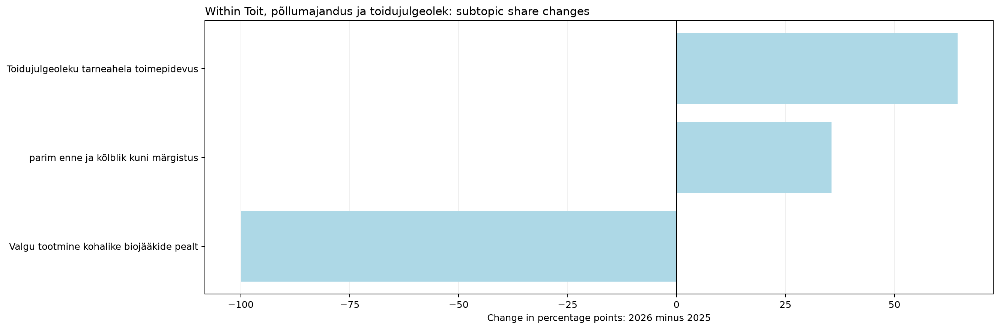

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
49,Toidujulgeoleku tarneahela toimepidevus,0.00,96.51,0.0,4.0,0.00,1.06,1.06,0.0,64.47,64.47,only_observed_2026,False,True
52,parim enne ja kõlblik kuni märgistus,0.00,53.19,0.0,1.0,0.00,0.58,0.58,0.0,35.53,35.53,only_observed_2026,False,False
223,Valgu tootmine kohalike biojääkide pealt,22.76,0.00,2.0,0.0,0.23,0.00,-0.23,100.0,0.00,-100.00,only_observed_2025,True,False


In [15]:
display(Image(filename=str(COMPARISON / "subtopics-food.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("food")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Riigijuhtimine, kodanikuühiskond ja õigus

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

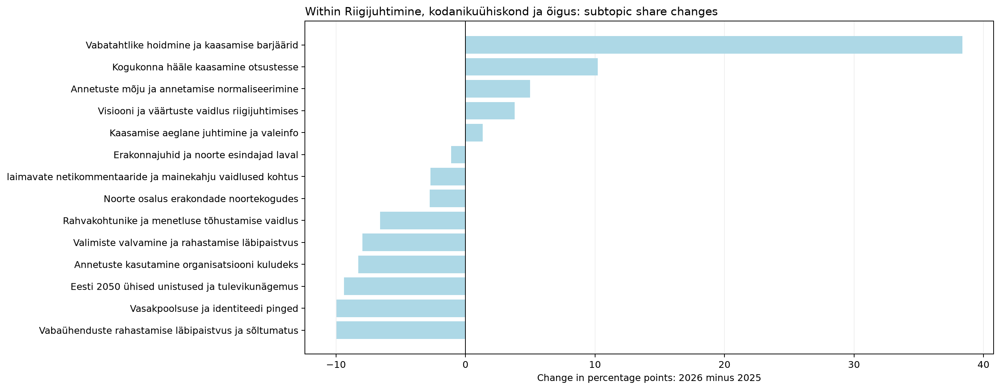

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
160,Vabatahtlike hoidmine ja kaasamise barjäärid,7.18,62.62,2.0,1.0,0.07,0.68,0.61,0.78,39.14,38.36,both_years,False,False
34,Kogukonna hääle kaasamine otsustesse,59.43,26.61,8.0,5.0,0.60,0.29,-0.31,6.42,16.63,10.22,both_years,True,True
129,Annetuste mõju ja annetamise normaliseerimine,97.99,24.93,3.0,3.0,0.99,0.27,-0.71,10.58,15.58,5.00,both_years,True,True
119,Visiooni ja väärtuste vaidlus riigijuhtimises,94.65,22.41,7.0,4.0,0.95,0.25,-0.71,10.22,14.01,3.79,both_years,True,True
234,Kaasamise aeglane juhtimine ja valeinfo,28.32,7.04,2.0,1.0,0.29,0.08,-0.21,3.06,4.40,1.34,both_years,True,False
218,Erakonnajuhid ja noorte esindajad laval,19.71,1.62,3.0,1.0,0.20,0.02,-0.18,2.13,1.01,-1.12,both_years,True,False
47,laimavate netikommentaaride ja mainekahju vaid...,91.16,11.41,1.0,1.0,0.92,0.12,-0.79,9.84,7.13,-2.71,both_years,False,False
148,Noorte osalus erakondade noortekogudes,25.55,0.00,2.0,0.0,0.26,0.00,-0.26,2.76,0.00,-2.76,only_observed_2025,True,False
36,Rahvakohtunike ja menetluse tõhustamise vaidlus,61.00,0.00,1.0,0.0,0.61,0.00,-0.61,6.59,0.00,-6.59,only_observed_2025,False,False
32,Valimiste valvamine ja rahastamise läbipaistvus,73.62,0.00,2.0,0.0,0.74,0.00,-0.74,7.95,0.00,-7.95,only_observed_2025,True,False


In [16]:
display(Image(filename=str(COMPARISON / "subtopics-governance.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("governance")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Tervishoid, ravi ja terviseandmed

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

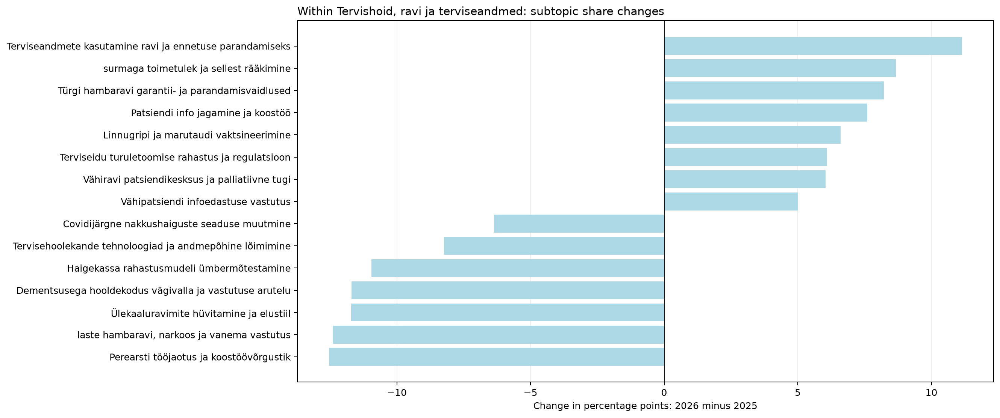

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
205,Terviseandmete kasutamine ravi ja ennetuse par...,8.76,122.28,2.0,4.0,0.09,1.34,1.25,1.29,12.43,11.14,both_years,False,True
85,surmaga toimetulek ja sellest rääkimine,6.21,94.29,1.0,3.0,0.06,1.03,0.97,0.91,9.58,8.67,both_years,False,True
59,Türgi hambaravi garantii- ja parandamisvaidlused,0.00,80.82,0.0,1.0,0.00,0.88,0.88,0.00,8.22,8.22,only_observed_2026,False,False
116,Patsiendi info jagamine ja koostöö,37.20,128.64,4.0,5.0,0.37,1.41,1.03,5.47,13.08,7.60,both_years,True,True
106,Linnugripi ja marutaudi vaktsineerimine,0.00,64.92,0.0,1.0,0.00,0.71,0.71,0.00,6.60,6.60,only_observed_2026,False,False
144,Terviseidu turuletoomise rahastus ja regulatsioon,13.68,79.73,2.0,3.0,0.14,0.87,0.73,2.01,8.10,6.09,both_years,True,True
3,Vähiravi patsiendikesksus ja palliatiivne tugi,16.00,82.55,1.0,4.0,0.16,0.90,0.74,2.35,8.39,6.04,both_years,False,True
154,Vähipatsiendi infoedastuse vastutus,3.18,53.75,1.0,2.0,0.03,0.59,0.56,0.47,5.46,5.00,both_years,False,True
138,AI roll arstide suhtluses ja vähiravis,7.53,58.14,1.0,3.0,0.08,0.64,0.56,1.11,5.91,4.80,both_years,False,True
152,Tervishoiu konkurentsi tasakaal,10.35,58.48,1.0,2.0,0.10,0.64,0.54,1.52,5.94,4.42,both_years,False,True


In [17]:
display(Image(filename=str(COMPARISON / "subtopics-healthcare.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("healthcare")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Rahvusvahelised suhted, Euroopa Liit ja humanitaarabi

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

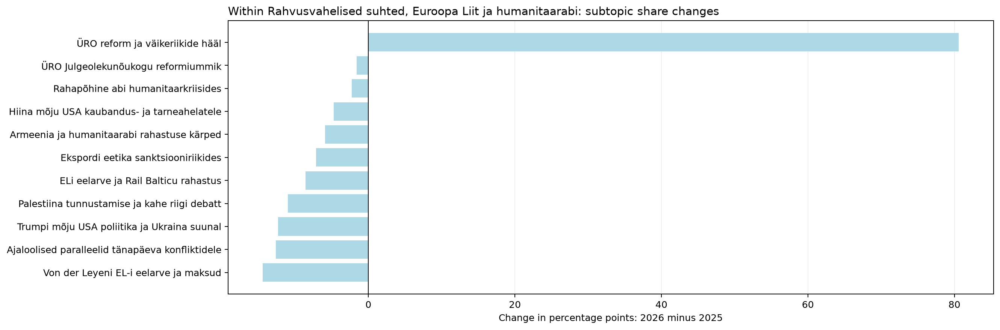

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
131,ÜRO reform ja väikeriikide hääl,72.66,77.64,4.0,1.0,0.73,0.85,0.12,11.76,92.35,80.59,both_years,True,False
229,ÜRO Julgeolekunõukogu reformiummik,9.86,0.00,1.0,0.0,0.10,0.00,-0.10,1.60,0.00,-1.60,only_observed_2025,False,False
193,Rahapõhine abi humanitaarkriisides,14.19,0.00,1.0,0.0,0.14,0.00,-0.14,2.30,0.00,-2.30,only_observed_2025,False,False
204,Hiina mõju USA kaubandus- ja tarneahelatele,41.23,1.63,4.0,1.0,0.42,0.02,-0.40,6.67,1.94,-4.73,both_years,True,False
98,Armeenia ja humanitaarabi rahastuse kärped,36.58,0.00,1.0,0.0,0.37,0.00,-0.37,5.92,0.00,-5.92,only_observed_2025,False,False
162,Ekspordi eetika sanktsiooniriikides,44.03,0.00,1.0,0.0,0.44,0.00,-0.44,7.13,0.00,-7.13,only_observed_2025,False,False
82,ELi eelarve ja Rail Balticu rahastus,52.90,0.00,1.0,0.0,0.53,0.00,-0.53,8.56,0.00,-8.56,only_observed_2025,False,False
9,Palestiina tunnustamise ja kahe riigi debatt,67.90,0.00,2.0,0.0,0.68,0.00,-0.68,10.99,0.00,-10.99,only_observed_2025,True,False
105,Trumpi mõju USA poliitika ja Ukraina suunal,111.43,4.80,5.0,1.0,1.12,0.05,-1.07,18.03,5.71,-12.32,both_years,True,False
198,Ajaloolised paralleelid tänapäeva konfliktidele,78.04,0.00,4.0,0.0,0.79,0.00,-0.79,12.63,0.00,-12.63,only_observed_2025,True,False


In [18]:
display(Image(filename=str(COMPARISON / "subtopics-international.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("international")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Meedia, avalik arutelu ja infokvaliteet

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

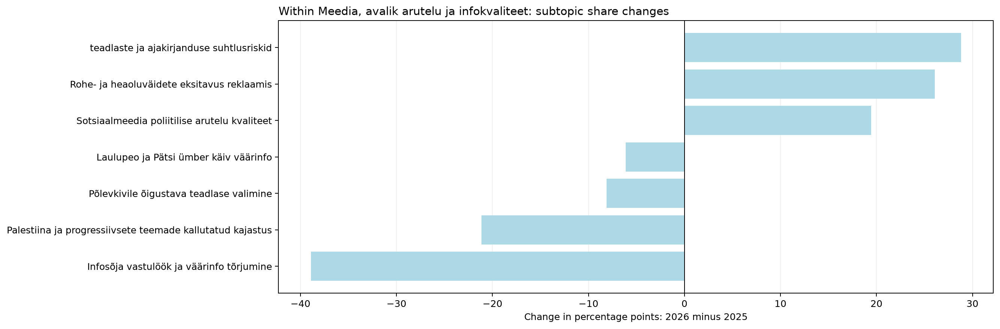

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
20,teadlaste ja ajakirjanduse suhtlusriskid,0.00,84.56,0.0,2.0,0.00,0.92,0.92,0.00,28.80,28.80,only_observed_2026,False,True
114,Rohe- ja heaolu­väidete eksitavus reklaamis,2.85,80.34,1.0,1.0,0.03,0.88,0.85,1.29,27.36,26.07,both_years,False,False
115,Sotsiaalmeedia poliitilise arutelu kvaliteet,20.39,84.07,4.0,2.0,0.21,0.92,0.71,9.20,28.63,19.43,both_years,True,True
216,Laulupeo ja Pätsi ümber käiv väärinfo,13.60,0.00,1.0,0.0,0.14,0.00,-0.14,6.14,0.00,-6.14,only_observed_2025,False,False
228,Põlevkivile õigustava teadlase valimine,18.02,0.00,1.0,0.0,0.18,0.00,-0.18,8.13,0.00,-8.13,only_observed_2025,False,False
220,Palestiina ja progressiivsete teemade kallutat...,46.82,0.00,2.0,0.0,0.47,0.00,-0.47,21.13,0.00,-21.13,only_observed_2025,True,False
149,Infosõja vastulöök ja väärinfo tõrjumine,119.89,44.66,5.0,6.0,1.21,0.49,-0.72,54.11,15.21,-38.90,both_years,True,True


In [19]:
display(Image(filename=str(COMPARISON / "subtopics-media.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("media")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Ränne, lõimumine ja kuuluvus

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

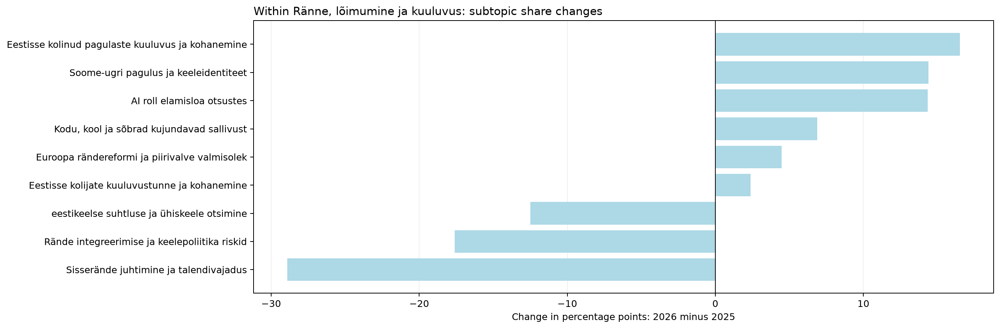

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
122,Eestisse kolinud pagulaste kuuluvus ja kohanemine,0.00,77.83,0.0,2.0,0.00,0.85,0.85,0.00,16.52,16.52,only_observed_2026,False,True
93,Soome-ugri pagulus ja keeleidentiteet,0.00,67.87,0.0,1.0,0.00,0.74,0.74,0.00,14.40,14.40,only_observed_2026,False,False
66,AI roll elamisloa otsustes,0.00,67.53,0.0,1.0,0.00,0.74,0.74,0.00,14.33,14.33,only_observed_2026,False,False
80,"Kodu, kool ja sõbrad kujundavad sallivust",22.38,82.73,3.0,4.0,0.23,0.90,0.68,10.67,17.56,6.89,both_years,True,True
207,Euroopa rändereformi ja piirivalve valmisolek,0.00,21.08,0.0,2.0,0.00,0.23,0.23,0.00,4.47,4.47,only_observed_2026,False,True
94,Eestisse kolijate kuuluvustunne ja kohanemine,31.45,81.89,2.0,6.0,0.32,0.90,0.58,15.00,17.38,2.38,both_years,True,True
75,eestikeelse suhtluse ja ühiskeele otsimine,29.18,6.77,3.0,2.0,0.29,0.07,-0.22,13.92,1.44,-12.48,both_years,True,False
134,Rände integreerimise ja keelepoliitika riskid,63.55,59.88,2.0,3.0,0.64,0.65,0.01,30.31,12.71,-17.60,both_years,True,True
188,Sisserände juhtimine ja talendivajadus,63.10,5.56,4.0,2.0,0.64,0.06,-0.58,30.10,1.18,-28.91,both_years,True,False


In [20]:
display(Image(filename=str(COMPARISON / "subtopics-migration.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("migration")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Loodus, metsandus ja maavarad

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

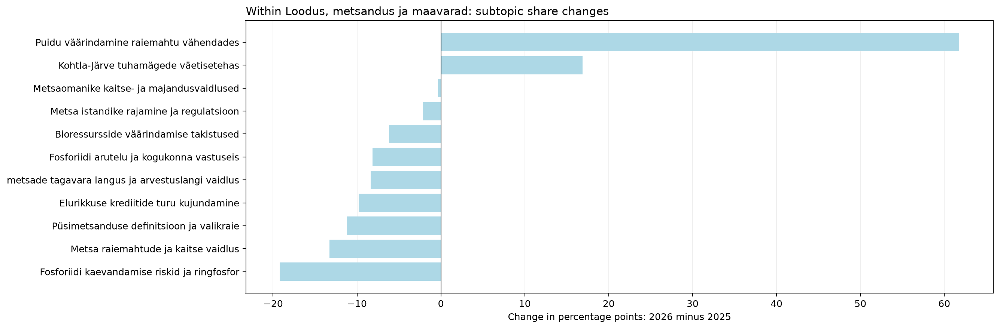

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
167,Puidu väärindamine raiemahtu vähendades,65.29,21.57,5.0,3.0,0.66,0.24,-0.42,8.33,70.12,61.80,both_years,True,True
70,Kohtla-Järve tuhamägede väetisetehas,6.06,5.44,1.0,1.0,0.06,0.06,-0.00,0.77,17.68,16.91,both_years,False,False
73,Metsaomanike kaitse- ja majandusvaidlused,98.17,3.75,4.0,1.0,0.99,0.04,-0.95,12.52,12.20,-0.33,both_years,True,False
222,Metsa istandike rajamine ja regulatsioon,16.95,0.00,1.0,0.0,0.17,0.00,-0.17,2.16,0.00,-2.16,only_observed_2025,False,False
221,Bioressursside väärindamise takistused,48.50,0.00,1.0,0.0,0.49,0.00,-0.49,6.19,0.00,-6.19,only_observed_2025,False,False
232,Fosforiidi arutelu ja kogukonna vastuseis,63.77,0.00,4.0,0.0,0.64,0.00,-0.64,8.13,0.00,-8.13,only_observed_2025,True,False
168,metsade tagavara langus ja arvestuslangi vaidlus,65.57,0.00,2.0,0.0,0.66,0.00,-0.66,8.36,0.00,-8.36,only_observed_2025,True,False
62,Elurikkuse krediitide turu kujundamine,76.84,0.00,1.0,0.0,0.77,0.00,-0.77,9.80,0.00,-9.80,only_observed_2025,False,False
56,Püsimetsanduse definitsioon ja valikraie,88.16,0.00,1.0,0.0,0.89,0.00,-0.89,11.25,0.00,-11.25,only_observed_2025,False,False
201,Metsa raiemahtude ja kaitse vaidlus,104.10,0.00,6.0,0.0,1.05,0.00,-1.05,13.28,0.00,-13.28,only_observed_2025,True,False


In [21]:
display(Image(filename=str(COMPARISON / "subtopics-nature.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("nature")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Eluase, ruum ja ühendused

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

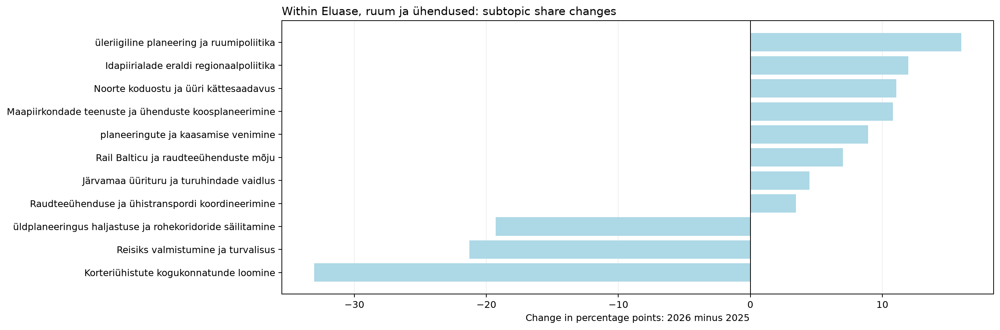

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
104,üleriigiline planeering ja ruumipoliitika,17.97,129.92,2.0,4.0,0.18,1.42,1.24,6.85,22.83,15.98,both_years,True,True
43,Idapiirialade eraldi regionaalpoliitika,3.31,75.28,1.0,1.0,0.03,0.82,0.79,1.26,13.23,11.96,both_years,False,False
57,Noorte koduostu ja üüri kättesaadavus,4.98,73.80,1.0,3.0,0.05,0.81,0.76,1.90,12.97,11.07,both_years,False,True
137,Maapiirkondade teenuste ja ühenduste koosplane...,11.44,86.22,2.0,5.0,0.12,0.94,0.83,4.36,15.15,10.79,both_years,True,True
95,planeeringute ja kaasamise venimine,14.13,81.35,1.0,6.0,0.14,0.89,0.75,5.39,14.29,8.91,both_years,False,True
63,Rail Balticu ja raudteeühenduste mõju,10.41,62.50,1.0,3.0,0.10,0.68,0.58,3.97,10.98,7.01,both_years,False,True
211,Järvamaa üürituru ja turuhindade vaidlus,0.00,25.45,0.0,1.0,0.00,0.28,0.28,0.00,4.47,4.47,only_observed_2026,False,False
194,Raudteeühenduse ja ühistranspordi koordineerimine,2.68,25.48,1.0,2.0,0.03,0.28,0.25,1.02,4.48,3.45,both_years,False,True
141,üldplaneeringus haljastuse ja rohekoridoride s...,54.86,9.17,1.0,1.0,0.55,0.10,-0.45,20.91,1.61,-19.30,both_years,False,False
28,Reisiks valmistumine ja turvalisus,55.83,0.00,1.0,0.0,0.56,0.00,-0.56,21.28,0.00,-21.28,only_observed_2025,False,False


In [22]:
display(Image(filename=str(COMPARISON / "subtopics-place.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("place")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Vaimne tervis, tervisekäitumine ja ennetus

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

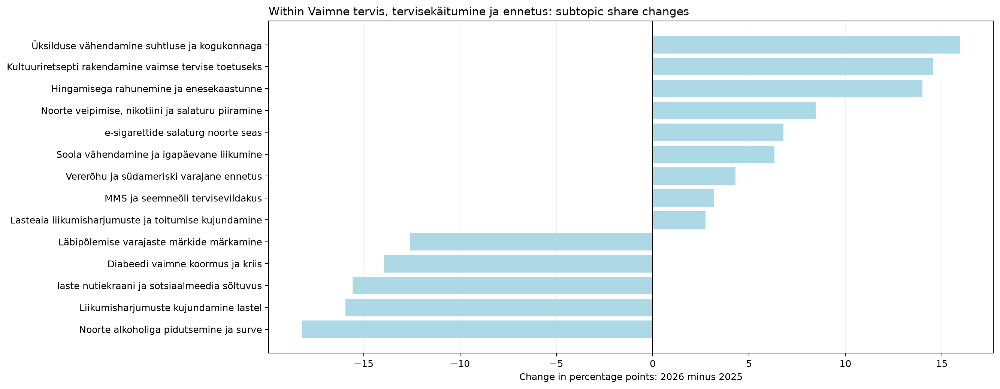

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
15,Üksilduse vähendamine suhtluse ja kogukonnaga,6.60,92.49,3.0,2.0,0.07,1.01,0.95,1.46,17.43,15.97,both_years,False,True
109,Kultuuriretsepti rakendamine vaimse tervise to...,0.00,77.15,0.0,1.0,0.00,0.84,0.84,0.00,14.54,14.54,only_observed_2026,False,False
100,Hingamisega rahunemine ja enesekaastunne,0.00,74.29,0.0,2.0,0.00,0.81,0.81,0.00,14.00,14.00,only_observed_2026,False,True
185,"Noorte veipimise, nikotiini ja salaturu piiramine",1.58,46.74,1.0,1.0,0.02,0.51,0.50,0.35,8.81,8.46,both_years,False,False
159,e-sigarettide salaturg noorte seas,0.00,35.96,0.0,1.0,0.00,0.39,0.39,0.00,6.78,6.78,only_observed_2026,False,False
192,Soola vähendamine ja igapäevane liikumine,13.53,49.40,1.0,3.0,0.14,0.54,0.40,2.99,9.31,6.32,both_years,False,True
33,Vererõhu ja südameriski varajane ennetus,8.13,32.36,1.0,2.0,0.08,0.35,0.27,1.79,6.10,4.30,both_years,False,True
208,MMS ja seemneõli tervisevildakus,7.17,25.32,1.0,2.0,0.07,0.28,0.20,1.58,4.77,3.19,both_years,False,True
197,Lasteaia liikumisharjumuste ja toitumise kujun...,0.00,14.59,0.0,1.0,0.00,0.16,0.16,0.00,2.75,2.75,only_observed_2026,False,False
164,Läbipõlemise varajaste märkide märkamine,74.46,20.37,5.0,3.0,0.75,0.22,-0.53,16.44,3.84,-12.60,both_years,True,True


In [23]:
display(Image(filename=str(COMPARISON / "subtopics-wellbeing.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("wellbeing")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Tööelu, juhtimine ja töötajate õigused

The chart compares subtopic shares **within this category**. The table also shows shares of all discussion time, so category growth and shifts in its composition can be distinguished.

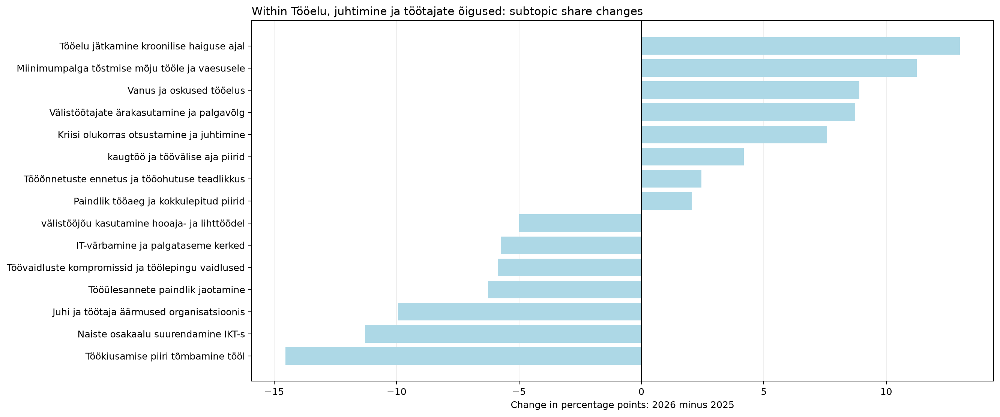

,jev_topic_name,minutes_2025,minutes_2026,talks_2025,talks_2026,time_share_2025,time_share_2026,time_share_delta_pp,within_parent_share_2025,within_parent_share_2026,within_parent_delta_pp,status,supported_2025,supported_2026
22,Tööelu jätkamine kroonilise haiguse ajal,0.00,84.34,0.0,1.0,0.00,0.92,0.92,0.00,13.01,13.01,only_observed_2026,False,False
72,Miinimumpalga tõstmise mõju tööle ja vaesusele,3.92,76.30,1.0,2.0,0.04,0.83,0.79,0.52,11.77,11.24,both_years,False,True
83,Vanus ja oskused tööelus,37.92,90.60,4.0,4.0,0.38,0.99,0.61,5.07,13.97,8.90,both_years,True,True
44,Välistöötajate ärakasutamine ja palgavõlg,0.00,56.62,0.0,1.0,0.00,0.62,0.62,0.00,8.73,8.73,only_observed_2026,False,False
139,Kriisi olukorras otsustamine ja juhtimine,13.56,60.89,4.0,3.0,0.14,0.67,0.53,1.81,9.39,7.58,both_years,True,True
91,kaugtöö ja töövälise aja piirid,12.15,37.70,2.0,3.0,0.12,0.41,0.29,1.63,5.81,4.19,both_years,True,True
2,Tööõnnetuste ennetus ja tööohutuse teadlikkus,85.02,89.61,1.0,1.0,0.86,0.98,0.12,11.37,13.82,2.45,both_years,False,False
169,Paindlik tööaeg ja kokkulepitud piirid,45.61,52.86,4.0,2.0,0.46,0.58,0.12,6.10,8.15,2.05,both_years,True,True
19,Töökiusu ja vaidluste piiritlemine töösuhtes,61.37,56.61,3.0,2.0,0.62,0.62,0.00,8.21,8.73,0.52,both_years,True,True
215,välistööjõu kasutamine hooaja- ja lihttöödel,45.37,6.93,1.0,1.0,0.46,0.08,-0.38,6.07,1.07,-5.00,both_years,False,False


In [24]:
display(Image(filename=str(COMPARISON / "subtopics-work.png")))
group = subtopics.loc[subtopics.jev_high_level_id.eq("work")].copy()
display(group.sort_values("within_parent_delta_pp", ascending=False)[
    ["jev_topic_name", "minutes_2025", "minutes_2026", "talks_2025", "talks_2026",
     "time_share_2025", "time_share_2026", "time_share_delta_pp",
     "within_parent_share_2025", "within_parent_share_2026", "within_parent_delta_pp",
     "status", "supported_2025", "supported_2026"]].round(2))


## Interpretation and written report

In [25]:
display(Markdown((COMPARISON / "COMPARISON.md").read_text()))

# Topic changes: 2025 vs 2026

This compares **available transcribed recordings**, not the complete festival programmes.
The corpus has 114 talks from 2025 and 105 from 2026. Podcast publication ends in
May 2026 for the 2025 subset and September 2026 for the 2026 subset; programme areas
may have been uploaded in batches. Apparent shifts can therefore reflect recording
availability and selected programme areas, not a change in society or festival-wide
priorities. No claim of significance or causal evolution is made.

The shared 236-topic Jev vocabulary and 20-category dictionary keep labels comparable.
Primary percentages use each year's **total segmented time, including unassigned**.
Talk coverage is the proportion of that year's talks containing a topic; it is
nonadditive. Segment-share and assigned-time-only alternatives are included in CSVs
(unassigned rows should not be interpreted as assigned-time shares).

Within-parent percentages divide each subtopic's time by its category's time in the
same year. A subtopic can gain global share just because its whole category grew;
within-parent changes show shifts in the category's composition. CSV decomposition
splits global change into parent expansion at the old mix, plus mix change at the
new parent size; it is an accounting identity whose components depend on ordering.

“Only observed in 2026/2025” means zero saved primary-label segments in the other
year, not that the subject was newly invented or disappeared. All such topics are
exported. A separate support flag requires at least 10 minutes across 2 talks in the
observed year; sparse examples remain visible. Categories/subtopics have no refit.

## What changed in these recordings

AI and digital technology expanded from 0.73% to 8.21% of discussion time (+7.47 percentage points); healthcare grew from 6.85% to 10.76% (+3.91 pp). Place/housing rose by 3.58 pp, migration by 3.04 pp and family by 2.87 pp. The largest decreases were governance (−7.58 pp), nature/forestry/resources (−7.56 pp), defence (−7.18 pp) and international affairs (−5.31 pp).

Inside AI, agent responsibility/control rose from 3.03% to 25.13% of AI time; prompt construction rose from 2.27% to 12.32%. AI impact on work fell from 55.19% to 20.90% of the category, while its share of ALL discussion time still increased by 1.31 pp. This is relative redistribution inside a much larger category, not disappearance of work-related AI.

Energy's overall share was almost stable (5.91% → 6.05%), yet its mix changed: electricity consumption/production targets rose from 4.51% to 21.45% of energy time, and exchange pricing from 0.82% to 13.47%. Biogas/hydrogen fell from 15.94% to 5.18%, and turbine infrasound from 11.47% to 0.40%.

Education slightly declined overall (13.73% → 12.45%), but early-childhood education responsibility/quality accounted for 17.71% of education in 2026 and had no primary-label segments in the 2025 sample. Within healthcare, health-data use grew from 1.29% to 12.43% of the category. These patterns can reflect the programme areas available in each recording subset.

## Main topic changes

| jev_high_level_name                                   |   time_share_2025 |   time_share_2026 |   time_share_delta_pp |   talk_coverage_2025 |   talk_coverage_2026 |
|:------------------------------------------------------|------------------:|------------------:|----------------------:|---------------------:|---------------------:|
| Tehisintellekt ja digitehnoloogia                     |              0.73 |              8.21 |                  7.47 |                 8.77 |                19.05 |
| Tervishoid, ravi ja terviseandmed                     |              6.85 |             10.76 |                  3.91 |                10.53 |                16.19 |
| Eluase, ruum ja ühendused                             |              2.64 |              6.23 |                  3.58 |                 7.02 |                10.48 |
| Ränne, lõimumine ja kuuluvus                          |              2.11 |              5.15 |                  3.04 |                 7.89 |                11.43 |
| Pere, suhted ja sooline võrdsus                       |              1.85 |              4.72 |                  2.87 |                 4.39 |                 5.71 |
| Laste ja noorte kaitse ning toetamine                 |              2.35 |              5.13 |                  2.78 |                 6.14 |                12.38 |
| Kultuur, loome ja pärand                              |              2.08 |              4.23 |                  2.16 |                 4.39 |                 4.76 |
| Toit, põllumajandus ja toidujulgeolek                 |              0.23 |              1.64 |                  1.41 |                 1.75 |                 4.76 |
| Vaimne tervis, tervisekäitumine ja ennetus            |              4.57 |              5.8  |                  1.24 |                14.91 |                15.24 |
| Küberturvalisus, privaatsus ja digiohud               |              1.39 |              2.61 |                  1.22 |                 5.26 |                10.48 |
| Meedia, avalik arutelu ja infokvaliteet               |              2.23 |              3.21 |                  0.98 |                 9.65 |                 7.62 |
| Kliima, rohepööre ja kestlik tarbimine                |              3.91 |              4.72 |                  0.81 |                20.18 |                13.33 |
| Energeetika ja energiaturud                           |              5.91 |              6.05 |                  0.14 |                13.16 |                11.43 |
| Majandus, ettevõtlus ja innovatsioon                  |              3.16 |              2.8  |                 -0.36 |                14.91 |                12.38 |
| Tööelu, juhtimine ja töötajate õigused                |              7.53 |              7.09 |                 -0.44 |                18.42 |                13.33 |
| Haridus, õppimine ja oskused                          |             13.73 |             12.45 |                 -1.28 |                36.84 |                27.62 |
| Määramata                                             |              7.15 |              5.26 |                 -1.89 |                71.05 |                71.43 |
| Rahvusvahelised suhted, Euroopa Liit ja humanitaarabi |              6.23 |              0.92 |                 -5.31 |                13.16 |                 1.9  |
| Riigikaitse, julgeolek ja kriisivalmidus              |              8.1  |              0.92 |                 -7.18 |                13.16 |                 4.76 |
| Loodus, metsandus ja maavarad                         |              7.9  |              0.34 |                 -7.56 |                11.4  |                 3.81 |
| Riigijuhtimine, kodanikuühiskond ja õigus             |              9.33 |              1.75 |                 -7.58 |                25.44 |                13.33 |

## Observed emergence and absence

44 detailed topics only observed in 2026 (18 meet the support flag); 61 only observed in 2025 (31 meet it).

### Only observed in 2026: largest by time share

| jev_topic_name                                        |   time_share_2026 |   minutes_2026 |   talks_2026 | supported_2026   |
|:------------------------------------------------------|------------------:|---------------:|-------------:|:-----------------|
| Alushariduse vastutus ja kvaliteet                    |              2.2  |         201.5  |            7 | True             |
| Toidujulgeoleku tarneahela toimepidevus               |              1.06 |          96.51 |            4 | True             |
| lapsevanema kaasamine lasteaia koostöösse             |              1.04 |          95    |            3 | True             |
| ravikindlustus vabakutselistele loovisikutele         |              0.95 |          86.47 |            2 | True             |
| teadlaste ja ajakirjanduse suhtlusriskid              |              0.92 |          84.56 |            2 | True             |
| Tööelu jätkamine kroonilise haiguse ajal              |              0.92 |          84.34 |            1 | False            |
| Türgi hambaravi garantii- ja parandamisvaidlused      |              0.88 |          80.82 |            1 | False            |
| AI päringute energiakulu läbipaistvus                 |              0.87 |          79.82 |            2 | True             |
| Grafiti, tänavakunsti ja lubade vahe                  |              0.86 |          78.75 |            1 | False            |
| Perearstikeskuste küberturvalisuse nõuded             |              0.85 |          78.09 |            1 | False            |
| Eestisse kolinud pagulaste kuuluvus ja kohanemine     |              0.85 |          77.83 |            2 | True             |
| Kultuuriretsepti rakendamine vaimse tervise toetuseks |              0.84 |          77.15 |            1 | False            |
| Autoriõigused ja AI treeningu läbipaistvus            |              0.82 |          75.37 |            3 | True             |
| AI-agentide volitamine isikukoodi kaudu               |              0.82 |          75.36 |            3 | True             |
| Käibemaksu ja toetuste mõju kultuurile                |              0.82 |          74.65 |            2 | True             |

### Only observed in 2025: largest by time share

| jev_topic_name                                       |   time_share_2025 |   minutes_2025 |   talks_2025 | supported_2025   |
|:-----------------------------------------------------|------------------:|---------------:|-------------:|:-----------------|
| Lai riigikaitse kodune ja kogukondlik valmisolek     |              2.11 |         209.54 |            7 | True             |
| Fosforiidi kaevandamise riskid ja ringfosfor         |              1.52 |         150.56 |            2 | True             |
| Kaitsekulude tõus ja hanked                          |              1.32 |         131.11 |            7 | True             |
| Metsa raiemahtude ja kaitse vaidlus                  |              1.05 |         104.1  |            6 | True             |
| Vabaühenduste rahastamise läbipaistvus ja sõltumatus |              0.93 |          92.4  |            2 | True             |
| Vasakpoolsuse ja identiteedi pinged                  |              0.93 |          92.21 |            2 | True             |
| Von der Leyeni EL-i eelarve ja maksud                |              0.9  |          89.11 |            3 | True             |
| Püsimetsanduse definitsioon ja valikraie             |              0.89 |          88.16 |            1 | False            |
| Korteriühistute kogukonnatunde loomine               |              0.87 |          86.7  |            1 | False            |
| Sooneutraalne ajateenistus ja reservi täitmine       |              0.85 |          84.6  |            4 | True             |
| Naiste osakaalu suurendamine IKT-s                   |              0.85 |          84.42 |            2 | True             |
| laste hambaravi, narkoos ja vanema vastutus          |              0.85 |          84.28 |            1 | False            |
| Noorte alkoholiga pidutsemine ja surve               |              0.83 |          82.56 |            1 | False            |
| naiste ajateenistuse laiendamine riigikaitses        |              0.82 |          81.8  |            3 | True             |
| Ukraina turule sisenemine kohaliku partneriga        |              0.81 |          80.25 |            3 | True             |

## Inside each main topic

### Tehisintellekt ja digitehnoloogia

| jev_topic_name                                  |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| AI mõju töökorraldusele ja tööturule            |                      55.19 |                      20.9  |                   -34.3  |                  1.31 |            7 |           12 |
| AI kasutamine töö- ja loometekstide koostamisel |                      31.25 |                       1.9  |                   -29.35 |                 -0.07 |            4 |            4 |
| AI-agentide vastutus ja kontroll                |                       3.03 |                      25.13 |                    22.1  |                  2.04 |            1 |            9 |
| AI-assistendi prompti ülesehitus                |                       2.27 |                      12.32 |                    10.05 |                  1    |            1 |            2 |
| Autoriõigused ja AI treeningu läbipaistvus      |                       0    |                      10.04 |                    10.04 |                  0.82 |            0 |            3 |

### Laste ja noorte kaitse ning toetamine

| jev_topic_name                               |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:---------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| lapsega esmakontakti loomine lastekaitses    |                      21.62 |                       1.19 |                   -20.43 |                 -0.45 |            1 |            2 |
| Laste internetikäitumine ja abiotsimine      |                      20.25 |                       1.14 |                   -19.11 |                 -0.42 |            4 |            1 |
| Lastekodukasvamise kogemus ja märkamise roll |                       6.39 |                      23.57 |                    17.18 |                  1.06 |            1 |            3 |
| Laste ja AI-petuste internetiohud            |                      18.07 |                       3.63 |                   -14.44 |                 -0.24 |            1 |            3 |
| Veebis lastega suhtlemise seksuaalriskid     |                       6.98 |                      17.77 |                    10.79 |                  0.75 |            3 |            1 |

### Kliima, rohepööre ja kestlik tarbimine

| jev_topic_name                                     |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:---------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| AI päringute energiakulu läbipaistvus              |                       0    |                      18.48 |                    18.48 |                  0.87 |            0 |            2 |
| Minimalistlik ökoeluviis ja piisavus               |                      15.4  |                       0    |                   -15.4  |                 -0.6  |            2 |            0 |
| kliimariski mõju vee- ja soojusvarustusele         |                       2.94 |                      17.46 |                    14.53 |                  0.71 |            2 |            4 |
| rohetehnoloogia investeeringute ja turu takistused |                      24.58 |                      12.36 |                   -12.22 |                 -0.38 |           12 |            5 |
| Rohetehnoloogia rahastus ja laenuotsused           |                      13.95 |                       2.13 |                   -11.82 |                 -0.44 |            4 |            1 |

### Kultuur, loome ja pärand

| jev_topic_name                                |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:----------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Koduloomuuseumi rahastamine ja jätkamine      |                      33.14 |                       0    |                   -33.14 |                 -0.69 |            1 |            0 |
| noorte filmiarutelud ja tagasiside            |                      28.86 |                       0    |                   -28.86 |                 -0.6  |            1 |            0 |
| Emadus ja koolikultuur kultuuri kandjana      |                      24.3  |                       0    |                   -24.3  |                 -0.5  |            2 |            0 |
| ravikindlustus vabakutselistele loovisikutele |                       0    |                      22.33 |                    22.33 |                  0.95 |            0 |            2 |
| Grafiti, tänavakunsti ja lubade vahe          |                       0    |                      20.34 |                    20.34 |                  0.86 |            0 |            1 |

### Küberturvalisus, privaatsus ja digiohud

| jev_topic_name                                 |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:-----------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Paroolide ja wifi kaudu levinud küberpettused  |                      46.88 |                       0    |                   -46.88 |                 -0.65 |            1 |            0 |
| andmejärelevalve ja tehisintellekti piirid     |                       9.02 |                      48.33 |                    39.32 |                  1.14 |            3 |            9 |
| Laste piltide postitamine vanemate poolt       |                      38.62 |                       0    |                   -38.62 |                 -0.54 |            1 |            0 |
| Perearstikeskuste küberturvalisuse nõuded      |                       0    |                      32.72 |                    32.72 |                  0.85 |            0 |            1 |
| Interneti solvangute ja ähvarduste ohjeldamine |                       5.49 |                      18.94 |                    13.46 |                  0.42 |            2 |            1 |

### Riigikaitse, julgeolek ja kriisivalmidus

| jev_topic_name                                   |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:-------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| CBRN-riskideks valmisoleku arutelu               |                       0    |                      88.43 |                    88.43 |                  0.81 |            0 |            1 |
| Lai riigikaitse kodune ja kogukondlik valmisolek |                      26.07 |                       0    |                   -26.07 |                 -2.11 |            7 |            0 |
| Kaitsekulude tõus ja hanked                      |                      16.31 |                       0    |                   -16.31 |                 -1.32 |            7 |            0 |
| Sooneutraalne ajateenistus ja reservi täitmine   |                      10.52 |                       0    |                   -10.52 |                 -0.85 |            4 |            0 |
| naiste ajateenistuse laiendamine riigikaitses    |                      10.18 |                       0    |                   -10.18 |                 -0.82 |            3 |            0 |

### Majandus, ettevõtlus ja innovatsioon

| jev_topic_name                                           |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:---------------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Startup-ökosüsteemi kogukond ja eeskujud                 |                       2.93 |                      29.1  |                    26.16 |                  0.72 |            2 |            3 |
| Ukraina turule sisenemine kohaliku partneriga            |                      25.57 |                       0    |                   -25.57 |                 -0.81 |            3 |            0 |
| Startupide registreerimise ja fondi-õiguse lihtsustamine |                       0    |                      22.83 |                    22.83 |                  0.64 |            0 |            2 |
| Väikeettevõtjate maksud, hanked ja eksport               |                      23.79 |                       1.27 |                   -22.52 |                 -0.72 |            5 |            2 |
| Majanduskasvu ja heaolu vaidlus                          |                      16.66 |                      26.17 |                     9.51 |                  0.21 |            9 |            3 |

### Haridus, õppimine ja oskused

| jev_topic_name                                       |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:-----------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Alushariduse vastutus ja kvaliteet                   |                       0    |                      17.71 |                    17.71 |                  2.2  |            0 |            7 |
| Eesti hariduse eesmärgid ja sihid                    |                      12.73 |                       2.33 |                   -10.39 |                 -1.46 |           19 |            4 |
| Lasteaia kvaliteet, märkamise ja toetuse roll        |                       0.2  |                      10.4  |                    10.2  |                  1.27 |            1 |            5 |
| lapsevanema kaasamine lasteaia koostöösse            |                       0    |                       8.35 |                     8.35 |                  1.04 |            0 |            3 |
| Teadmussiirdedoktorantuuri ettevõtluslik praktilisus |                       1.2  |                       7.84 |                     6.64 |                  0.81 |            2 |            3 |

### Energeetika ja energiaturud

| jev_topic_name                                    |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:--------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Eesti elektritarbimise ja tootmise sihid          |                       4.51 |                      21.45 |                    16.94 |                  1.03 |            4 |            7 |
| Elektribörsi hinnakujunduse jaotumine             |                       0.82 |                      13.47 |                    12.65 |                  0.77 |            1 |            3 |
| Tuulikuinfraheli häirivuse ja tervisemõju vaidlus |                      11.47 |                       0.4  |                   -11.07 |                 -0.65 |            2 |            1 |
| Biogaasi ja vesiniku kasutus Eestis               |                      15.94 |                       5.18 |                   -10.76 |                 -0.63 |            4 |            6 |
| Tuuleparkide kaasamise usalduskriis               |                       9.92 |                       1.27 |                    -8.66 |                 -0.51 |            1 |            2 |

### Pere, suhted ja sooline võrdsus

| jev_topic_name                                   |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:-------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| sündimuse toetamine läbi perekindluse            |                      50.18 |                       0.76 |                   -49.43 |                 -0.89 |            2 |            1 |
| Õige keha- ja seksuaalsõnavara õpetamine         |                      26.97 |                       0.38 |                   -26.59 |                 -0.48 |            1 |            1 |
| Emaduse karjäärikaod ja naasmine tööle           |                       1.44 |                      20.45 |                    19.01 |                  0.94 |            1 |            3 |
| Naiste juhtide ja isade rolliootused             |                       2.06 |                      17.64 |                    15.58 |                  0.8  |            2 |            3 |
| Istanbuli konventsiooni vaidlused ja rakendamine |                       7.26 |                      20.63 |                    13.38 |                  0.84 |            1 |            1 |

### Toit, põllumajandus ja toidujulgeolek

| jev_topic_name                           |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:-----------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Valgu tootmine kohalike biojääkide pealt |                        100 |                       0    |                  -100    |                 -0.23 |            2 |            0 |
| Toidujulgeoleku tarneahela toimepidevus  |                          0 |                      64.47 |                    64.47 |                  1.06 |            0 |            4 |
| parim enne ja kõlblik kuni märgistus     |                          0 |                      35.53 |                    35.53 |                  0.58 |            0 |            1 |

### Riigijuhtimine, kodanikuühiskond ja õigus

| jev_topic_name                                       |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:-----------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Vabatahtlike hoidmine ja kaasamise barjäärid         |                       0.78 |                      39.14 |                    38.36 |                  0.61 |            2 |            1 |
| Kogukonna hääle kaasamine otsustesse                 |                       6.42 |                      16.63 |                    10.22 |                 -0.31 |            8 |            5 |
| Vabaühenduste rahastamise läbipaistvus ja sõltumatus |                       9.98 |                       0    |                    -9.98 |                 -0.93 |            2 |            0 |
| Vasakpoolsuse ja identiteedi pinged                  |                       9.96 |                       0    |                    -9.96 |                 -0.93 |            2 |            0 |
| Eesti 2050 ühised unistused ja tulevikunägemus       |                      11.49 |                       2.1  |                    -9.39 |                 -1.04 |            6 |            1 |

### Tervishoid, ravi ja terviseandmed

| jev_topic_name                                           |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:---------------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Perearsti tööjaotus ja koostöövõrgustik                  |                      13.93 |                       1.39 |                   -12.54 |                 -0.8  |            4 |            1 |
| laste hambaravi, narkoos ja vanema vastutus              |                      12.4  |                       0    |                   -12.4  |                 -0.85 |            1 |            0 |
| Ülekaaluravimite hüvitamine ja elustiil                  |                      11.71 |                       0    |                   -11.71 |                 -0.8  |            1 |            0 |
| Dementsusega hooldekodus vägivalla ja vastutuse arutelu  |                      11.69 |                       0    |                   -11.69 |                 -0.8  |            1 |            0 |
| Terviseandmete kasutamine ravi ja ennetuse parandamiseks |                       1.29 |                      12.43 |                    11.14 |                  1.25 |            2 |            4 |

### Rahvusvahelised suhted, Euroopa Liit ja humanitaarabi

| jev_topic_name                                  |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| ÜRO reform ja väikeriikide hääl                 |                      11.76 |                      92.35 |                    80.59 |                  0.12 |            4 |            1 |
| Von der Leyeni EL-i eelarve ja maksud           |                      14.42 |                       0    |                   -14.42 |                 -0.9  |            3 |            0 |
| Ajaloolised paralleelid tänapäeva konfliktidele |                      12.63 |                       0    |                   -12.63 |                 -0.79 |            4 |            0 |
| Trumpi mõju USA poliitika ja Ukraina suunal     |                      18.03 |                       5.71 |                   -12.32 |                 -1.07 |            5 |            1 |
| Palestiina tunnustamise ja kahe riigi debatt    |                      10.99 |                       0    |                   -10.99 |                 -0.68 |            2 |            0 |

### Meedia, avalik arutelu ja infokvaliteet

| jev_topic_name                                            |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:----------------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Infosõja vastulöök ja väärinfo tõrjumine                  |                      54.11 |                      15.21 |                   -38.9  |                 -0.72 |            5 |            6 |
| teadlaste ja ajakirjanduse suhtlusriskid                  |                       0    |                      28.8  |                    28.8  |                  0.92 |            0 |            2 |
| Rohe- ja heaolu­väidete eksitavus reklaamis               |                       1.29 |                      27.36 |                    26.07 |                  0.85 |            1 |            1 |
| Palestiina ja progressiivsete teemade kallutatud kajastus |                      21.13 |                       0    |                   -21.13 |                 -0.47 |            2 |            0 |
| Sotsiaalmeedia poliitilise arutelu kvaliteet              |                       9.2  |                      28.63 |                    19.43 |                  0.71 |            4 |            2 |

### Ränne, lõimumine ja kuuluvus

| jev_topic_name                                    |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:--------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Sisserände juhtimine ja talendivajadus            |                      30.1  |                       1.18 |                   -28.91 |                 -0.58 |            4 |            2 |
| Rände integreerimise ja keelepoliitika riskid     |                      30.31 |                      12.71 |                   -17.6  |                  0.01 |            2 |            3 |
| Eestisse kolinud pagulaste kuuluvus ja kohanemine |                       0    |                      16.52 |                    16.52 |                  0.85 |            0 |            2 |
| Soome-ugri pagulus ja keeleidentiteet             |                       0    |                      14.4  |                    14.4  |                  0.74 |            0 |            1 |
| AI roll elamisloa otsustes                        |                       0    |                      14.33 |                    14.33 |                  0.74 |            0 |            1 |

### Loodus, metsandus ja maavarad

| jev_topic_name                               |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:---------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Puidu väärindamine raiemahtu vähendades      |                       8.33 |                      70.12 |                    61.8  |                 -0.42 |            5 |            3 |
| Fosforiidi kaevandamise riskid ja ringfosfor |                      19.2  |                       0    |                   -19.2  |                 -1.52 |            2 |            0 |
| Kohtla-Järve tuhamägede väetisetehas         |                       0.77 |                      17.68 |                    16.91 |                 -0    |            1 |            1 |
| Metsa raiemahtude ja kaitse vaidlus          |                      13.28 |                       0    |                   -13.28 |                 -1.05 |            6 |            0 |
| Püsimetsanduse definitsioon ja valikraie     |                      11.25 |                       0    |                   -11.25 |                 -0.89 |            1 |            0 |

### Eluase, ruum ja ühendused

| jev_topic_name                                           |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:---------------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Korteriühistute kogukonnatunde loomine                   |                      33.05 |                       0    |                   -33.05 |                 -0.87 |            1 |            0 |
| Reisiks valmistumine ja turvalisus                       |                      21.28 |                       0    |                   -21.28 |                 -0.56 |            1 |            0 |
| üldplaneeringus haljastuse ja rohekoridoride säilitamine |                      20.91 |                       1.61 |                   -19.3  |                 -0.45 |            1 |            1 |
| üleriigiline planeering ja ruumipoliitika                |                       6.85 |                      22.83 |                    15.98 |                  1.24 |            2 |            4 |
| Idapiirialade eraldi regionaalpoliitika                  |                       1.26 |                      13.23 |                    11.96 |                  0.79 |            1 |            1 |

### Vaimne tervis, tervisekäitumine ja ennetus

| jev_topic_name                                        |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:------------------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Noorte alkoholiga pidutsemine ja surve                |                      18.23 |                       0    |                   -18.23 |                 -0.83 |            1 |            0 |
| Üksilduse vähendamine suhtluse ja kogukonnaga         |                       1.46 |                      17.43 |                    15.97 |                  0.95 |            3 |            2 |
| Liikumisharjumuste kujundamine lastel                 |                      16.67 |                       0.72 |                   -15.94 |                 -0.72 |            2 |            2 |
| laste nutiekraani ja sotsiaalmeedia sõltuvus          |                      26.54 |                      10.97 |                   -15.57 |                 -0.58 |            6 |            3 |
| Kultuuriretsepti rakendamine vaimse tervise toetuseks |                       0    |                      14.54 |                    14.54 |                  0.84 |            0 |            1 |

### Tööelu, juhtimine ja töötajate õigused

| jev_topic_name                                 |   within_parent_share_2025 |   within_parent_share_2026 |   within_parent_delta_pp |   time_share_delta_pp |   talks_2025 |   talks_2026 |
|:-----------------------------------------------|---------------------------:|---------------------------:|-------------------------:|----------------------:|-------------:|-------------:|
| Töökiusamise piiri tõmbamine tööl              |                      16.48 |                       1.94 |                   -14.54 |                 -1.1  |            3 |            1 |
| Tööelu jätkamine kroonilise haiguse ajal       |                       0    |                      13.01 |                    13.01 |                  0.92 |            0 |            1 |
| Naiste osakaalu suurendamine IKT-s             |                      11.29 |                       0    |                   -11.29 |                 -0.85 |            2 |            0 |
| Miinimumpalga tõstmise mõju tööle ja vaesusele |                       0.52 |                      11.77 |                    11.24 |                  0.79 |            1 |            2 |
| Juhi ja töötaja äärmused organisatsioonis      |                      10.96 |                       1.01 |                    -9.95 |                 -0.75 |            2 |            3 |



## Individual semantic segments in 2D

Each equal-sized point is **one native semantic segment**, not a topic centroid. Color shows the high-level category mapped from the segment's Jev primary topic; gray points are unassigned. The combined view has 4,132 points; the 2025 and 2026 views have 2,154 and 1,978. All three share coordinates and axes, allowing comparison without separately fitting each year.

Positions come from one UMAP projection of the saved 1,024-dimensional BGE **segment embeddings**, with cosine distance, 15 neighbors, minimum distance 0.15 and seed 42. Topic labels are only used for color, not as projection inputs. Nearby points can have similar text, but 2D distances and apparent clusters are approximate and are not a new clustering result.

The interactive plots support zooming, category filtering via the legend and hover with talk title, year, timestamps, detailed topic and a text excerpt. Static PNGs are embedded immediately below each interactive view. Regenerate with `uv run --group topic-analysis python scripts/export_jev_segment_maps.py`; it reuses cached vectors and projection coordinates without classifier API calls.

### Combined: 4,132 segments

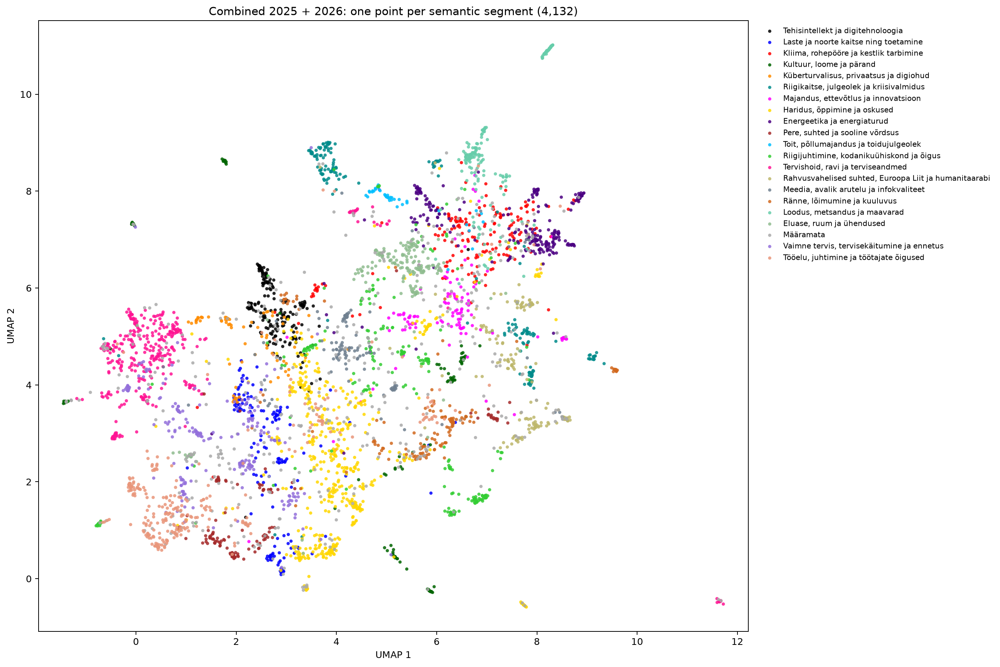

### 2025: 2,154 segments

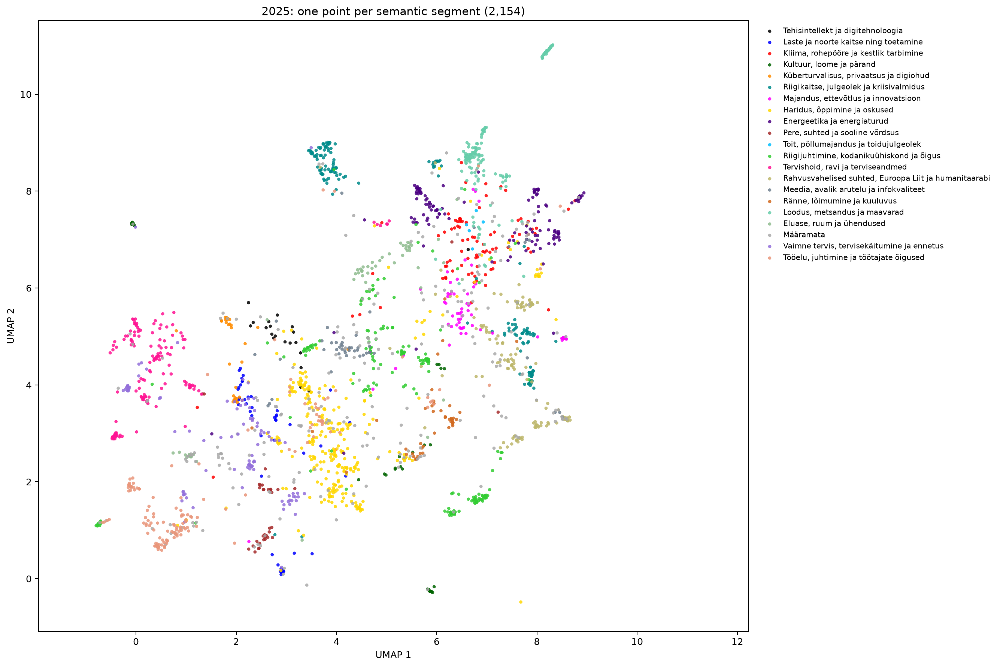

### 2026: 1,978 segments

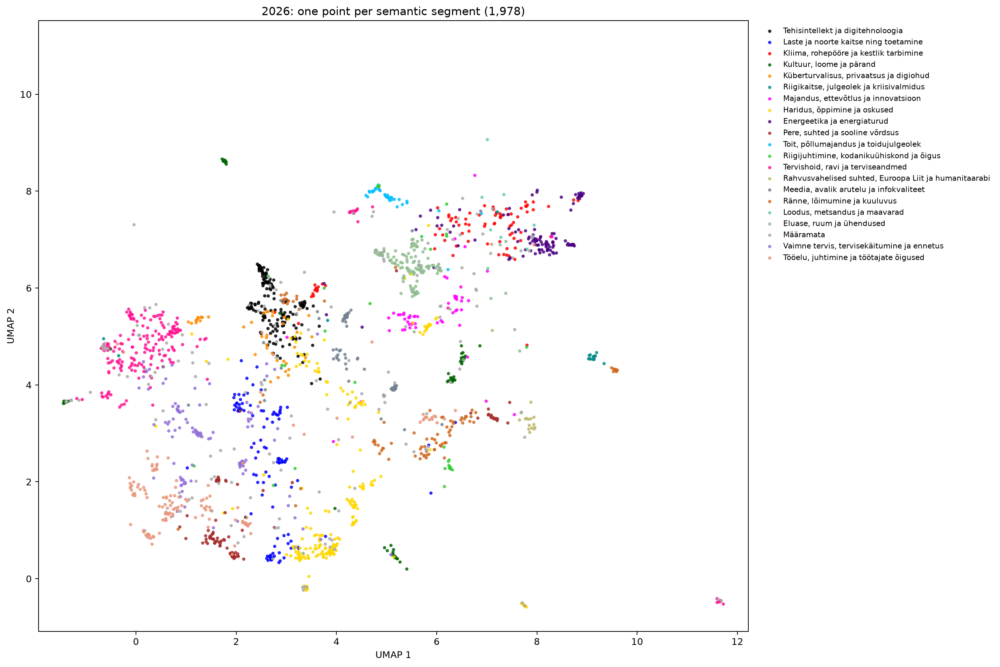

In [1]:
from pathlib import Path
import plotly.io as pio
from IPython.display import Image, Markdown, display
segment_map_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
segment_maps = segment_map_root / "data/topic-analysis/results/jev-semantic-all/segment-maps"
for scope, label in [("all", "Combined: 4,132 segments"), ("2025", "2025: 2,154 segments"),
                     ("2026", "2026: 1,978 segments")]:
    display(Markdown("### " + label))
    figure = pio.from_json((segment_maps / (scope + ".plotly.json")).read_text())
    display(figure)
    display(Image(filename=str(segment_maps / (scope + ".png"))))
